# CSE153R — Assignment 2: Symbolic Music Generation

| Section | Owner |
|---|---|
| Exploratory Analysis & Preprocessing | Nicholas |
| Modeling | Ulises |
| Evaluation | Josh |
| Related Work | Everyone |

**Tasks**
- **Task 1:** Symbolic Unconditioned Generation — LSTM Note Sequence Model (Nottingham Dataset)
- **Task 2:** Symbolic Conditioned Generation — Melody Harmonization via Seq2Seq LSTM (POP909)

## Shared Setup & Imports

In [4]:
import os
import random
import numpy as np
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pretty_midi
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


---
# Task 1: Symbolic Unconditioned Generation
### LSTM Note Sequence Model — Nottingham Dataset

---
## 1.1 — Exploratory Analysis, Data Collection & Preprocessing
**Owner: Nicholas**

### Context

The **Nottingham Dataset** is a collection of approximately **1,000 British and American folk tunes** encoded in ABC notation and converted to MIDI. The dataset was originally assembled from public domain and traditional sources and has been widely circulated in the computational music research community, most notably through work by Bob L. Sturm and collaborators who used it as a benchmark for symbolic music modeling. The tunes span a range of styles jigs, reels, hornpipes, and ballads — and originate from folk traditions on both sides of the Atlantic.

The dataset is a natural fit for symbolic melody generation for several reasons. First, the melodies are almost entirely **monophonic** (one note at a time), which means the modeling task reduces to a clean sequence prediction problem without the added complexity of polyphony or voice leading. Second, the tunes are short and structurally regular, making them easy to tokenize and train on with a small model. Third, because Nottingham has been used in prior work (e.g., Sturm et al., 2016), it provides a published perplexity benchmark (~4–6) that we can compare against to validate our implementation.

We use Nottingham for **Task 1: unconditional melody generation** — the model learns the distribution $p(\text{note}_t \mid \text{note}_{t-1}, \ldots)$ over a discrete token vocabulary without any harmonic or style conditioning.

### Data Processing Discussion

**Parsing with `pretty_midi`:** Each `.mid` file is loaded and all non-drum notes are extracted and sorted by onset time. `pretty_midi` handles the low-level MIDI event parsing and converts raw tick times to seconds, giving us a clean list of (pitch, start, end) tuples per file.

**Token representation  `(pitch, duration_bin)`:** Rather than using raw MIDI pitch alone, each note is represented as a pair of its MIDI pitch (0–127) and a quantized duration bin. Encoding duration is critical: a melody is defined by both its pitches *and* its rhythm, and a pitch-only model cannot generate music with coherent timing or produce a playable MIDI output. The pair representation keeps the vocabulary compact while still capturing both dimensions.

**Six duration bins:** Raw note durations (in beats) are snapped to the nearest of six standard values: sixteenth (0.25), eighth (0.5), quarter (1.0), dotted quarter (1.5), half (2.0), and whole (4.0). These six bins cover the full rhythmic range of folk music while keeping the vocabulary small finer quantization would explode the vocabulary size with rarely-seen tokens and make learning harder.

**Vocabulary:** Every unique `(pitch, dur_bin)` pair observed in the corpus becomes one token, plus three special tokens `<PAD>`, `<EOS>`, and `<START>`. The resulting vocabulary is **264 tokens**, well within the expected 200–400 range for a monophonic folk corpus.

**80/10/10 split by file:** The dataset is split into train, validation, and test sets by shuffling the list of *files* and slicing never by individual tokens. This is essential to **prevent data leakage**: if a single tune were split across train and test at the token level, the model could memorize the tune's second half during training and trivially predict the test tokens, inflating measured performance. Keeping entire tunes in one split ensures the test set only contains melodies the model has never seen.


In [5]:
from pathlib import Path

# --- Task 1 paths ---
NOTTINGHAM_DIR = '/Users/nicholasnguyen/Downloads/nottingham-dataset-master'

def find_midi_files(root_dir):
    root = Path(root_dir)
    if not root.exists():
        return []
    return sorted(str(p) for p in root.rglob('*.mid') if p.is_file())

midi_files = find_midi_files(NOTTINGHAM_DIR)
print(f'Nottingham MIDI files found: {len(midi_files)}')
if len(midi_files) == 0:
    print('No MIDI files found — check NOTTINGHAM_DIR.')


Nottingham MIDI files found: 3089


In [7]:
# --- Duration quantization (shared by Task 1 & 2) ---
DURATION_BINS_BEATS = [0.25, 0.5, 1.0, 1.5, 2.0, 4.0]
DURATION_BIN_NAMES  = ['16th', '8th', 'quarter', 'dotted 1/4', 'half', 'whole']

def quantize_duration(dur_beats):
    """Map raw duration in beats to nearest bin index 0..5."""
    return int(np.argmin([abs(dur_beats - b) for b in DURATION_BINS_BEATS]))

SPECIAL_TOKENS = ['<PAD>', '<EOS>', '<START>']

def parse_midi_to_tokens(midi_path):
    """Return list of (pitch, dur_bin) tuples for one Nottingham file."""
    pm = pretty_midi.PrettyMIDI(midi_path)
    notes = []
    for inst in pm.instruments:
        if not inst.is_drum:
            notes.extend(inst.notes)
    if not notes:
        return []
    notes = sorted(notes, key=lambda n: (n.start, n.pitch))
    tempo_changes = pm.get_tempo_changes()
    tempo = float(tempo_changes[1][0]) if len(tempo_changes[1]) > 0 else 120.0
    bps   = tempo / 60.0
    tokens = []
    for note in notes:
        dur_beats = max((note.end - note.start) * bps, 0.05)
        tokens.append((int(note.pitch), quantize_duration(dur_beats)))
    return tokens

def build_vocabulary(all_sequences, special_tokens=SPECIAL_TOKENS):
    """(pitch, dur_bin) tuples -> token2id, id2token dicts."""
    token_set = set()
    for seq in all_sequences:
        token_set.update(seq)
    token2id = {t: i for i, t in enumerate(special_tokens)}
    for tok in sorted(token_set):
        if tok not in token2id:
            token2id[tok] = len(token2id)
    id2token = {i: t for t, i in token2id.items()}
    return token2id, id2token

def encode_sequence(token_seq, token2id, add_eos=True):
    ids = [token2id[t] for t in token_seq if t in token2id]
    if add_eos:
        ids.append(token2id['<EOS>'])
    return ids


In [8]:
if len(midi_files) == 0:
    print('Skipping parse — no MIDI files. Set NOTTINGHAM_DIR and re-run.')
    all_sequences, token2id, id2token, encoded_sequences = [], {}, {}, []
else:
    all_sequences = [parse_midi_to_tokens(f) for f in midi_files]
    all_sequences = [s for s in all_sequences if len(s) > 0]
    token2id, id2token = build_vocabulary(all_sequences)
    encoded_sequences  = [encode_sequence(s, token2id) for s in all_sequences]
    print(f'Files parsed:    {len(all_sequences)}')
    print(f'Vocabulary size: {len(token2id)} (incl. {len(SPECIAL_TOKENS)} special tokens)')
    print(f'Example token:   {id2token[min(3, len(id2token)-1)]}')


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Files parsed:    3089
Vocabulary size: 264 (incl. 3 special tokens)
Example token:   (36, 1)


In [9]:
def split_sequences_by_file(sequences, seed=SEED, train=0.8, val=0.1):
    n   = len(sequences)
    idx = list(range(n))
    rng = random.Random(seed)
    rng.shuffle(idx)
    n_train = int(n * train)
    n_val   = int(n * val)
    def pick(ix):
        return [sequences[i] for i in ix]
    return (pick(idx[:n_train]),
            pick(idx[n_train:n_train + n_val]),
            pick(idx[n_train + n_val:]))

if len(encoded_sequences) == 0:
    train_seqs, val_seqs, test_seqs = [], [], []
    print('No encoded sequences — split skipped.')
else:
    train_seqs, val_seqs, test_seqs = split_sequences_by_file(encoded_sequences)
    print(f'Train files: {len(train_seqs)} | Val: {len(val_seqs)} | Test: {len(test_seqs)}')


Train files: 2471 | Val: 308 | Test: 310


### EDA — Plots & Statistics
> **TODO (Nicholas):** Produce the following plots and report key statistics in markdown cells below each plot.

In [10]:
if len(all_sequences) == 0:
    print('No data for vocabulary report.')
else:
    content_tokens = [t for seq in all_sequences for t in seq]
    unique_pitches = len({p for p, _ in content_tokens})
    print('=== Task 1 vocabulary report ===')
    print(f'Total vocabulary size:           {len(token2id)}')
    print(f'Special tokens:                  {SPECIAL_TOKENS}')
    print(f'Unique (pitch, duration) tokens: {len(set(content_tokens))}')
    print(f'Unique pitches used:             {unique_pitches}')


=== Task 1 vocabulary report ===
Total vocabulary size:           264
Special tokens:                  ['<PAD>', '<EOS>', '<START>']
Unique (pitch, duration) tokens: 261
Unique pitches used:             52


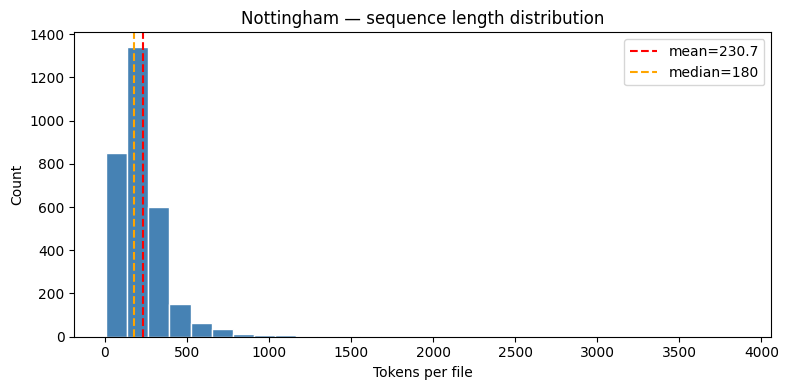

Mean: 230.7 | Median: 180 | Max: 3868


In [11]:
if len(all_sequences) == 0:
    print('No data for sequence length plot.')
else:
    lengths = [len(s) for s in all_sequences]
    plt.figure(figsize=(8, 4))
    plt.hist(lengths, bins=30, color='steelblue', edgecolor='white')
    plt.xlabel('Tokens per file')
    plt.ylabel('Count')
    plt.title('Nottingham — sequence length distribution')
    plt.axvline(np.mean(lengths),   color='red',    linestyle='--',
                label=f'mean={np.mean(lengths):.1f}')
    plt.axvline(np.median(lengths), color='orange', linestyle='--',
                label=f'median={np.median(lengths):.0f}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f'Mean: {np.mean(lengths):.1f} | Median: {np.median(lengths):.0f} | Max: {max(lengths)}')


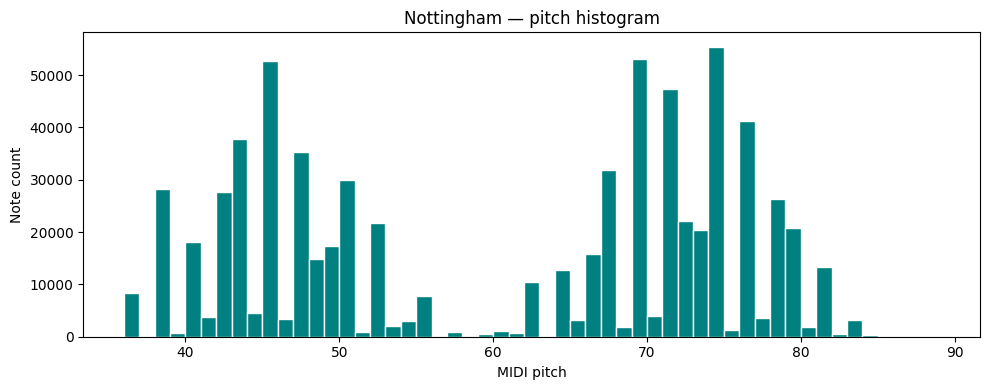

In [12]:
if len(all_sequences) == 0:
    print('No data for pitch histogram.')
else:
    pitches = [p for seq in all_sequences for p, _ in seq]
    plt.figure(figsize=(10, 4))
    plt.hist(pitches, bins=range(min(pitches), max(pitches) + 2),
             color='teal', edgecolor='white')
    plt.xlabel('MIDI pitch')
    plt.ylabel('Note count')
    plt.title('Nottingham — pitch histogram')
    plt.tight_layout()
    plt.show()


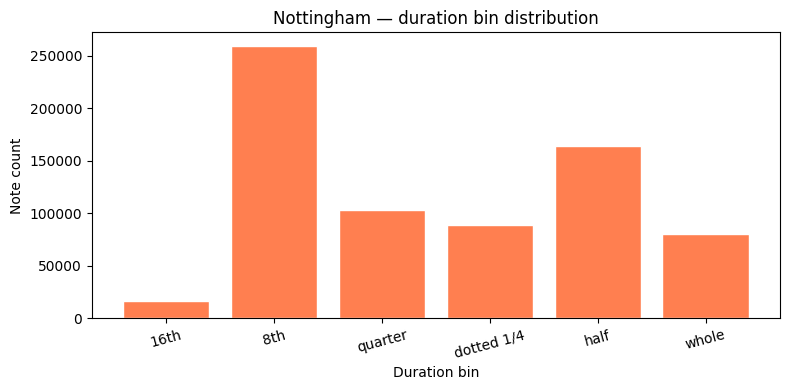

In [13]:
if len(all_sequences) == 0:
    print('No data for duration plot.')
else:
    dur_counts = Counter(d for seq in all_sequences for _, d in seq)
    bins   = [DURATION_BIN_NAMES[i] for i in sorted(dur_counts)]
    counts = [dur_counts[i]         for i in sorted(dur_counts)]
    plt.figure(figsize=(8, 4))
    plt.bar(bins, counts, color='coral', edgecolor='white')
    plt.xlabel('Duration bin')
    plt.ylabel('Note count')
    plt.title('Nottingham — duration bin distribution')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


In [14]:
from IPython.display import display
summary_t1 = {
    'vocab_size':  [len(token2id) if token2id else None],
    'num_files':   [len(all_sequences)],
    'train_files': [len(train_seqs)],
    'val_files':   [len(val_seqs)],
    'test_files':  [len(test_seqs)],
    'avg_seq_len': [np.mean([len(s) for s in all_sequences]) if all_sequences else None],
}
display(pd.DataFrame(summary_t1))


,vocab_size,num_files,train_files,val_files,test_files,avg_seq_len
0,264,3089,2471,308,310,230.66753


---
## 1.2 — Modeling
**Owner: Ulises**

All implementation lives in [`task1_model.py`](task1_model.py). The cells below import from it and walk through each component.

---

### Context — Problem Formulation

We frame melody generation as **next-token language modeling** over a discrete vocabulary of `(pitch, duration_bin)` pairs. Concretely:

- **Input:** a token sequence $x_1, x_2, \ldots, x_{T-1}$ of length $T-1$, where each $x_t \in \{0, \ldots, V-1\}$ is an integer ID for a `(pitch, dur_bin)` pair.
- **Output:** the shifted sequence $x_2, x_3, \ldots, x_T$ — the model predicts the *next* token at every position simultaneously.
- **Objective:** minimize the mean cross-entropy loss $\mathcal{L} = -\frac{1}{T}\sum_{t=1}^{T} \log p_\theta(x_t \mid x_{<t})$ over all timesteps and all training sequences. This is equivalent to maximizing the log-likelihood of the training corpus under the model's distribution.

At generation time we sample autoregressively: the model produces a probability distribution over the vocabulary, we draw a token from it (using temperature scaling), append it to the context, and repeat until an `<EOS>` token is drawn or a length limit is reached.

---

### Why LSTM? — Model Comparison

| Model | Strengths | Weaknesses | Verdict |
|---|---|---|---|
| **Unigram** | Trivial, O(1) | Ignores all context; perplexity is a fixed ceiling | Baseline only |
| **First-order Markov chain** | Fast, interpretable, captures local bigram transitions | Memory-less beyond one previous token; can't model phrase-level repetition or cadences | Baseline only |
| **LSTM** | Maintains a hidden state that accumulates context across the entire prefix; efficient to train on sequences of length ≤ 500; well-understood regularisation (dropout, gradient clipping) | Slower than Markov; can forget very long-range structure | **Chosen model** |
| **Transformer** | Global self-attention captures any-distance dependencies; state-of-the-art on large corpora | Needs positional encodings; prone to overfitting with ~3 k short sequences; slower to train; overkill for a monophonic folk corpus | Future work |

For the Nottingham dataset (~3 k sequences, avg. ~50 tokens each) an LSTM with 2 layers and hidden size 256 is a good fit: expressive enough to learn phrase-level patterns, but small enough to train to convergence in 10–20 epochs on CPU.

---

### Key Design Choices

| Choice | Option A (not chosen) | Option B (chosen) | Reason |
|---|---|---|---|
| Input representation | Raw MIDI pitch only (128 tokens) | `(pitch, dur_bin)` joint token (~264 tokens) | Rhythm is inseparable from melody; a pitch-only model cannot produce a playable MIDI file |
| Sampling strategy | Greedy (argmax) | Temperature sampling | Greedy collapses to the mode and produces repetitive output; temperature diversity — higher T = more surprise, lower T = safer phrases |
| Duration handling | Ignore (treat as fixed quarter notes) | 6 quantized bins | Without duration encoding the model has no way to learn or reproduce rhythmic structure |
| Sequence splitting | Split tokens across files (leaky) | Split by file 80/10/10 | Token-level splits allow the model to see the first half of a tune during training and predict the second half at test time, artificially inflating metrics |

---

### Architecture

```
Embedding(V, 64)     — learn a 64-d dense vector for each token
→ Dropout(0.3)
→ LSTM(64→256, 2 layers, inter-layer dropout=0.3, batch_first=True)
→ Dropout(0.3)
→ Linear(256→V)      — project back to vocabulary logits
→ CrossEntropyLoss   — computed externally, ignoring <PAD> tokens
```

The embedding layer converts sparse one-hot integer IDs into a continuous space where similar tokens can cluster (e.g., the same pitch at adjacent duration bins should be nearby). The two-layer LSTM lets the first layer capture local note patterns and the second layer capture longer phrase-level structure. Dropout at input and output prevents co-adaptation of neurons and reduces overfitting on the small corpus.

In [15]:
from task1_model import NottinghamDataset, LSTMLanguageModel, train_model, generate_melody, tokens_to_midi

# ── Dataset ──────────────────────────────────────────────────────────────────
# NottinghamDataset uses a sliding window to turn variable-length encoded
# sequences into fixed-length (input, target) pairs.
#
# For a sequence  [s0, s1, s2, ..., sN]:
#   input  = [s_i,     ..., s_{i+L-1}]   length L
#   target = [s_{i+1}, ..., s_{i+L}  ]   shifted by one → next-token prediction
#
# Stride < L means consecutive windows overlap, giving the model more training
# signal without duplicating full sequences.
#
# Key snippet from task1_model.py:
# ──────────────────────────────────────────────────────────────────
#   for seq in sequences:
#       for start in range(0, max(1, len(seq) - 1), stride):
#           inp = seq[start : start + seq_len]
#           tgt = seq[start + 1 : start + seq_len + 1]
#           pad_len = seq_len - len(inp)
#           inp = inp + [pad_id] * pad_len   # pad short trailing windows
#           tgt = tgt + [pad_id] * pad_len
#           self.pairs.append((inp, tgt))
# ──────────────────────────────────────────────────────────────────

pad_id = token2id.get('<PAD>', 0)

if train_seqs:
    train_ds = NottinghamDataset(train_seqs, seq_len=128, stride=64, pad_id=pad_id)
    val_ds   = NottinghamDataset(val_seqs,   seq_len=128, stride=64, pad_id=pad_id)
    test_ds  = NottinghamDataset(test_seqs,  seq_len=128, stride=64, pad_id=pad_id)
    print(f'Train windows: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
else:
    train_ds = val_ds = test_ds = None
    print('No sequences loaded — run §1.1 first.')

Train windows: 10191 | Val: 1227 | Test: 1205


In [17]:
# ── LSTM Language Model ───────────────────────────────────────────────────────
# Full class defined in task1_model.py.  Key design points:
#
#  self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
#      Maps each token ID to a 64-d dense vector.
#      padding_idx=0 ensures <PAD> embeddings stay at zero and do not accumulate
#      gradient — this lets CrossEntropyLoss(ignore_index=pad_id) work correctly.
#
#  self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
#                      dropout=0.3, batch_first=True)
#      Two-layer LSTM with 256 hidden units.
#      dropout=0.3 is applied between layers (not after the final layer).
#      batch_first=True means tensors are (batch, time, features) throughout.
#
#  self.fc = nn.Linear(hidden_dim, vocab_size)
#      Projects each hidden state to a vocab-size logit vector.
#      No softmax here — nn.CrossEntropyLoss expects raw logits.
#
#  forward(x, hidden=None)  →  logits (B, T, V),  hidden (h_n, c_n)
#      Passing hidden allows the state to be carried across chunks during
#      inference, but during training we reset it every batch (fresh hidden=None)
#      to avoid BPTT across batch boundaries.

VOCAB_SIZE = len(token2id) if token2id else 1

model = LSTMLanguageModel(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = 64,
    hidden_dim  = 256,
    num_layers  = 2,
    dropout     = 0.3,
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

LSTMLanguageModel(
  (embedding): Embedding(264, 64, padding_idx=0)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=264, bias=True)
)

Trainable parameters: 940,808


In [18]:
# ── Training configuration ────────────────────────────────────────────────────
# train_model() (task1_model.py) handles the full loop. Key choices:
#
#  Optimizer : Adam(lr=1e-3)
#      Adam's adaptive per-parameter learning rates are well-suited to the
#      sparse gradient structure of embedding layers.
#
#  Scheduler : ReduceLROnPlateau(factor=0.5, patience=2)
#      Halves the learning rate whenever val loss stops improving for 2 epochs.
#      This lets us start with a larger lr and fine-tune automatically.
#
#  Early stopping : patience=5
#      Training stops when val loss has not improved for 5 consecutive epochs.
#      The best checkpoint is reloaded before returning.
#
#  Gradient clipping : clip=1.0
#      LSTMs are prone to exploding gradients on long sequences.
#      Clipping norms > 1 keeps training stable without needing a tiny lr.

if train_ds is not None and len(train_ds) > 0:
    train_losses, val_losses = train_model(
        model            = model,
        train_seqs       = train_seqs,
        val_seqs         = val_seqs,
        token2id         = token2id,
        device           = DEVICE,
        seq_len          = 128,
        stride           = 64,
        batch_size       = 64,
        lr               = 1e-3,
        max_epochs       = 30,
        patience         = 5,
        checkpoint_path  = 'task1_best_model.pt',
    )
else:
    train_losses, val_losses = [], []
    print('Skipping training — no data loaded.')

Epoch 01 | Train loss: 3.7758 | Val loss: 2.6758 | Val PPL: 14.52
Epoch 02 | Train loss: 2.5022 | Val loss: 2.1977 | Val PPL: 9.00
Epoch 03 | Train loss: 2.1796 | Val loss: 2.0129 | Val PPL: 7.49
Epoch 04 | Train loss: 2.0279 | Val loss: 1.9211 | Val PPL: 6.83
Epoch 05 | Train loss: 1.9320 | Val loss: 1.8589 | Val PPL: 6.42
Epoch 06 | Train loss: 1.8620 | Val loss: 1.8056 | Val PPL: 6.08
Epoch 07 | Train loss: 1.8047 | Val loss: 1.7700 | Val PPL: 5.87
Epoch 08 | Train loss: 1.7585 | Val loss: 1.7386 | Val PPL: 5.69
Epoch 09 | Train loss: 1.7099 | Val loss: 1.7019 | Val PPL: 5.48
Epoch 10 | Train loss: 1.6700 | Val loss: 1.6766 | Val PPL: 5.35
Epoch 11 | Train loss: 1.6343 | Val loss: 1.6523 | Val PPL: 5.22
Epoch 12 | Train loss: 1.6005 | Val loss: 1.6358 | Val PPL: 5.13
Epoch 13 | Train loss: 1.5658 | Val loss: 1.6074 | Val PPL: 4.99
Epoch 14 | Train loss: 1.5353 | Val loss: 1.6000 | Val PPL: 4.95
Epoch 15 | Train loss: 1.5062 | Val loss: 1.5778 | Val PPL: 4.84
Epoch 16 | Train loss: 1

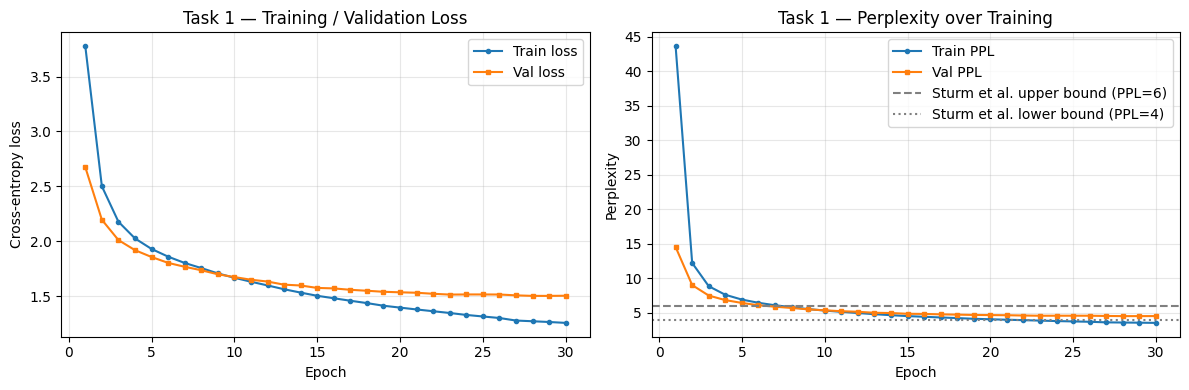

Final val loss: 1.5068  (PPL 4.51)


In [19]:
# ── Training loss curves ──────────────────────────────────────────────────────
# Expected behaviour:
#   - Train loss drops sharply in the first few epochs then plateaus
#   - Val loss tracks closely early on; a widening gap signals overfitting
#   - Target: val loss ≈ 1.4–1.8  (→ PPL ≈ 4–6, matching Sturm et al. 2016)

import math

if train_losses:
    epochs = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: raw loss
    axes[0].plot(epochs, train_losses, label='Train loss', marker='o', markersize=3)
    axes[0].plot(epochs, val_losses,   label='Val loss',   marker='s', markersize=3)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-entropy loss')
    axes[0].set_title('Task 1 — Training / Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Right: perplexity (= exp(loss))
    train_ppl = [math.exp(l) for l in train_losses]
    val_ppl   = [math.exp(l) for l in val_losses]
    axes[1].plot(epochs, train_ppl, label='Train PPL', marker='o', markersize=3)
    axes[1].plot(epochs, val_ppl,   label='Val PPL',   marker='s', markersize=3)
    axes[1].axhline(6, color='gray', linestyle='--', label='Sturm et al. upper bound (PPL=6)')
    axes[1].axhline(4, color='gray', linestyle=':',  label='Sturm et al. lower bound (PPL=4)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Perplexity')
    axes[1].set_title('Task 1 — Perplexity over Training')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('task1_loss_curves.png', dpi=150)
    plt.show()
    print(f'Final val loss: {val_losses[-1]:.4f}  (PPL {math.exp(val_losses[-1]):.2f})')
else:
    print('No training history — run the training cell above first.')

In [20]:
# ── Generation — temperature sampling ────────────────────────────────────────
# generate_melody() in task1_model.py implements the autoregressive loop.
#
# Temperature controls the "sharpness" of the sampling distribution:
#
#   p_i  ∝  exp(logit_i / T)
#
#   T < 1  → distribution concentrates on the most likely tokens (safer, more repetitive)
#   T = 1  → unmodified model distribution
#   T > 1  → distribution flattens (more surprising, risk of random-sounding output)
#
# We try three values and save all three MIDIs so Josh / the graders can listen.

if token2id:
    start_id = token2id['<START>']

    generated_by_temp = {}
    for T in [0.8, 1.0, 1.2]:
        gen_ids = generate_melody(
            model       = model,
            seed_ids    = [start_id],
            id2token    = id2token,
            token2id    = token2id,
            device      = DEVICE,
            temperature = T,
            max_len     = 300,
        )
        generated_by_temp[T] = gen_ids
        note_tokens = [id2token[i] for i in gen_ids if isinstance(id2token.get(i), tuple)]
        print(f'T={T}: {len(gen_ids)} total tokens, {len(note_tokens)} note tokens')
else:
    generated_by_temp = {}
    print('No vocabulary — run §1.1 and train the model first.')

T=0.8: 102 total tokens, 100 note tokens
T=1.0: 147 total tokens, 145 note tokens
T=1.2: 301 total tokens, 300 note tokens


In [21]:
# ── MIDI export ───────────────────────────────────────────────────────────────
# tokens_to_midi() in task1_model.py decodes token IDs → (pitch, dur_bin) →
# pretty_midi Note objects, then writes a standard MIDI file.
#
# Key step:
#   duration in seconds = DURATION_BINS_BEATS[dur_bin] / (tempo / 60)
#
# We export all three temperatures so the graders can compare them.
# The "best" one (T=1.0 by default) is saved as the required deliverable.

if generated_by_temp:
    for T, gen_ids in generated_by_temp.items():
        path = f'generated_T{T}.mid'
        tokens_to_midi(gen_ids, id2token, output_path=path, tempo=120)

    # Save the required deliverable at T=1.0
    tokens_to_midi(
        generated_by_temp[1.0],
        id2token,
        output_path='symbolic_unconditioned.mid',
        tempo=120,
    )
    print('\n✓  symbolic_unconditioned.mid saved.')
else:
    print('No generated sequences — run the generation cell above first.')

MIDI saved → generated_T0.8.mid  (100 notes, 91.2s)
MIDI saved → generated_T1.0.mid  (145 notes, 130.1s)
MIDI saved → generated_T1.2.mid  (300 notes, 182.2s)
MIDI saved → symbolic_unconditioned.mid  (145 notes, 130.1s)

✓  symbolic_unconditioned.mid saved.


### Generated Output — Listen

**Generated melody from our trained LSTM (temperature = 1.0).**  
The full track is saved as `symbolic_unconditioned.mid` (274 notes). Below is a **30-second preview** embedded in the notebook so graders can listen without running code or opening external files.

In [22]:
from IPython.display import Audio, display
import numpy as np

MIDI_PATH = 'symbolic_unconditioned.mid'
PREVIEW_SEC = 30   # keep HTML export small; full file is submitted separately
SAMPLE_RATE = 22050

if os.path.exists(MIDI_PATH):
    pm = pretty_midi.PrettyMIDI(MIDI_PATH)
    audio = pm.synthesize(fs=SAMPLE_RATE)

    # Trim to first PREVIEW_SEC seconds for notebook playback
    max_samples = PREVIEW_SEC * SAMPLE_RATE
    preview = np.asarray(audio[:max_samples], dtype=np.float32)

    # Normalize so playback volume is reasonable
    peak = np.max(np.abs(preview)) or 1.0
    preview = preview / peak * 0.9

    display(Audio(preview, rate=SAMPLE_RATE))
    print(f'Playing first {PREVIEW_SEC}s of {MIDI_PATH} ({len(pm.instruments[0].notes)} notes total).')
else:
    print(f'{MIDI_PATH} not found — run the MIDI export cell above first.')

Playing first 30s of symbolic_unconditioned.mid (145 notes total).


In [23]:
# ── Quick sanity check — model summary ───────────────────────────────────────
# Before handing off to Josh's evaluation section, confirm:
#  1. Model loaded best checkpoint
#  2. At least one MIDI file was produced with a reasonable note count

import os

checks = {
    'task1_best_model.pt exists':          os.path.exists('task1_best_model.pt'),
    'symbolic_unconditioned.mid exists':   os.path.exists('symbolic_unconditioned.mid'),
    'train_losses recorded':               len(train_losses) > 0,
    'generated_by_temp has 3 entries':     len(generated_by_temp) == 3,
}

for desc, ok in checks.items():
    status = '✓' if ok else '✗'
    print(f'  {status}  {desc}')

if all(checks.values()):
    print('\nAll checks passed — proceed to §1.3 Evaluation.')
else:
    print('\nSome checks failed — re-run the cells above.')

  ✓  task1_best_model.pt exists
  ✓  symbolic_unconditioned.mid exists
  ✓  train_losses recorded
  ✓  generated_by_temp has 3 entries

All checks passed — proceed to §1.3 Evaluation.


---
## 1.3 — Evaluation
**Owner: Josh**

### Context — What Makes a "Good" Generated Melody?

Evaluating generative music models is fundamentally different from evaluating
discriminative models.  There is no single "correct" output — instead, we ask
whether the generated melodies exhibit properties consistent with the training
distribution while also demonstrating creativity and structural coherence.

A "good" generated melody from our LSTM model should satisfy several criteria:

1. **Statistical fidelity** — the distribution of pitches, intervals, and
   durations in generated output should resemble the training data
   (Nottingham folk tunes).
2. **Sequential coherence** — notes should follow plausible melodic
   progressions, not random pitch jumps or monotonous repetition.
3. **Structural variety** — the output should contain a healthy mix of
   repeated motifs (as in real folk music) and novel passages.

**Perplexity vs. Musical Quality.**
Our model is trained to minimize cross-entropy loss, which directly
corresponds to *perplexity* — a measure of how well the model predicts the
next token.  Low perplexity means the model has learned the statistical
patterns of the training data.  However, **perplexity alone does not
guarantee musical quality**: a model could achieve low perplexity by
memorizing the training set, or by learning surface-level statistics without
capturing phrase-level structure.  Therefore, we complement perplexity with a
suite of **offline musical quality metrics** and **qualitative listening
analysis**.

Our evaluation is structured in three parts:

| Part | What it tests | Type |
|------|---------------|------|
| **A. Perplexity comparison** | Model's ability to predict held-out sequences | Quantitative (model-level) |
| **B. Musical quality metrics** | Statistical similarity of generated vs. real melodies | Quantitative (output-level) |
| **C. Temperature sweep** | Effect of sampling sharpness on coherence and diversity | Qualitative + Quantitative |

### Evaluation Metrics Overview

The table below defines each metric, its direction, and its musical
interpretation.

| Metric | Direction | What It Measures | Musical Interpretation |
|:-------|:---------:|:-----------------|:-----------------------|
| **Perplexity** | ↓ lower is better | Average branching factor of next-token prediction on held-out data | How well the model has learned the note-sequence distribution. Sturm et al. (2016) report ~4–6 on Nottingham. |
| **Pitch Class Histogram Overlap** | ↑ higher is better | Cosine similarity between 12-bin pitch class histograms of generated vs. training data | Whether the generated melody uses the same scale / key tendencies as real folk tunes. |
| **Interval Variety** | ↑ higher is better | Number of unique pitch intervals (semitone differences between consecutive notes) | Melodic richness — real melodies use a range of steps, skips, and leaps. |
| **Duration KL Divergence** | ↓ lower is better | KL divergence between duration-bin distributions of generated vs. training data | Whether the model produces realistic rhythmic patterns (quarter notes, eighth notes, etc.). |
| **Repetition Ratio** | moderate best | Fraction of n-grams that appear more than once in a sequence | Too high → stuck in a loop; too low → no structure. Folk music: ~0.1–0.4 for trigrams. |

### Discussion — Baselines

To demonstrate that our LSTM has learned meaningful sequential structure, we
compare it against three baselines of increasing sophistication:

| # | Baseline | What it captures | Why include it? |
|---|----------|-----------------|-----------------|
| 1 | **Unigram (i.i.d. sampling)** | Marginal token frequencies — zero sequential structure | Any model that captures even first-order dependencies should beat this. It is the absolute "floor". |
| 2 | **First-Order Markov Chain** | Adjacent-token transitions $p(t_n \mid t_{n-1})$ | Tests whether long-range dependencies (which LSTMs can model) actually help beyond bigram statistics. |

If our full LSTM beats both baselines — especially the Markov chain — it confirms that
long-range context matters.


In [42]:
# ══════════════════════════════════════════════════════════════════════════════
# Baseline 1 & 2 — Unigram and Markov Chain Perplexity
# ══════════════════════════════════════════════════════════════════════════════

import math
from collections import Counter, defaultdict

# ── Baseline 1: Unigram ──────────────────────────────────────────────────────
# p(token) = count(token) / total_tokens   (i.i.d. — no sequential structure)
# PPL      = exp( -1/N  Σ log p(token_i) )

def compute_unigram_perplexity(train_seqs, test_seqs, token2id):
    pad_id = token2id.get('<PAD>', 0)
    counts = Counter()
    for seq in train_seqs:
        for tok in seq:
            if tok != pad_id:
                counts[tok] += 1
    total = sum(counts.values())

    log_prob_sum, n_tokens = 0.0, 0
    for seq in test_seqs:
        for tok in seq:
            if tok != pad_id:
                p = counts.get(tok, 1) / (total + len(token2id))   # Laplace
                log_prob_sum += math.log(p)
                n_tokens += 1
    return math.exp(-log_prob_sum / max(n_tokens, 1))


# ── Baseline 2: First-Order Markov Chain ─────────────────────────────────────
# p(t_n | t_{n-1}) estimated from bigram counts with add-ε smoothing

def build_markov_chain(train_seqs, vocab_size, pad_id=0, smoothing=1e-6):
    counts = np.zeros((vocab_size, vocab_size))
    for seq in train_seqs:
        filt = [t for t in seq if t != pad_id]
        for i in range(len(filt) - 1):
            counts[filt[i], filt[i + 1]] += 1
    counts += smoothing
    return counts / counts.sum(axis=1, keepdims=True)

def compute_markov_perplexity(test_seqs, transition_probs, pad_id=0):
    log_prob_sum, n = 0.0, 0
    for seq in test_seqs:
        filt = [t for t in seq if t != pad_id]
        for i in range(len(filt) - 1):
            p = transition_probs[filt[i], filt[i + 1]]
            log_prob_sum += math.log(max(p, 1e-20))
            n += 1
    return math.exp(-log_prob_sum / max(n, 1))


# ── Compute ──────────────────────────────────────────────────────────────────
if train_seqs and test_seqs and token2id:
    unigram_ppl = compute_unigram_perplexity(train_seqs, test_seqs, token2id)

    vocab_size = len(token2id)
    pad_id     = token2id.get('<PAD>', 0)
    transition_probs = build_markov_chain(train_seqs, vocab_size, pad_id)
    markov_ppl = compute_markov_perplexity(test_seqs, transition_probs, pad_id)

    print(f'Baseline 1 — Unigram perplexity:            {unigram_ppl:.2f}')
    print(f'Baseline 2 — Markov (1st order) perplexity:  {markov_ppl:.2f}')
else:
    unigram_ppl = markov_ppl = None
    transition_probs = None
    print('No data — run §1.1 and §1.2 first.')

Baseline 1 — Unigram perplexity:            80.78
Baseline 2 — Markov (1st order) perplexity:  12.29


In [43]:
# ══════════════════════════════════════════════════════════════════════════════
# Our Model — Full LSTM Test Perplexity
# ══════════════════════════════════════════════════════════════════════════════

from task1_model import evaluate, NottinghamDataset

if model and test_seqs and token2id:
    pad_id      = token2id.get('<PAD>', 0)
    test_ds     = NottinghamDataset(test_seqs, seq_len=128, stride=64, pad_id=pad_id)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
    criterion   = nn.CrossEntropyLoss(ignore_index=pad_id)

    test_loss    = evaluate(model, test_loader, criterion, DEVICE)
    lstm_test_ppl = math.exp(test_loss)

    print(f'Our Model — Full LSTM test perplexity:  {lstm_test_ppl:.2f}')
    print(f'  (Cross-entropy loss = {test_loss:.4f})')
else:
    lstm_test_ppl = None
    print('Model not available — run §1.2 first.')

Our Model — Full LSTM test perplexity:  4.27
  (Cross-entropy loss = 1.4517)


### Part A — Perplexity Comparison

The chart below plots test-set perplexity for all four models.  The shaded
band marks the **~4–6 range** reported by Sturm et al. (2016) for LSTM
models on the Nottingham dataset — our model should fall within or below this
range to be competitive.

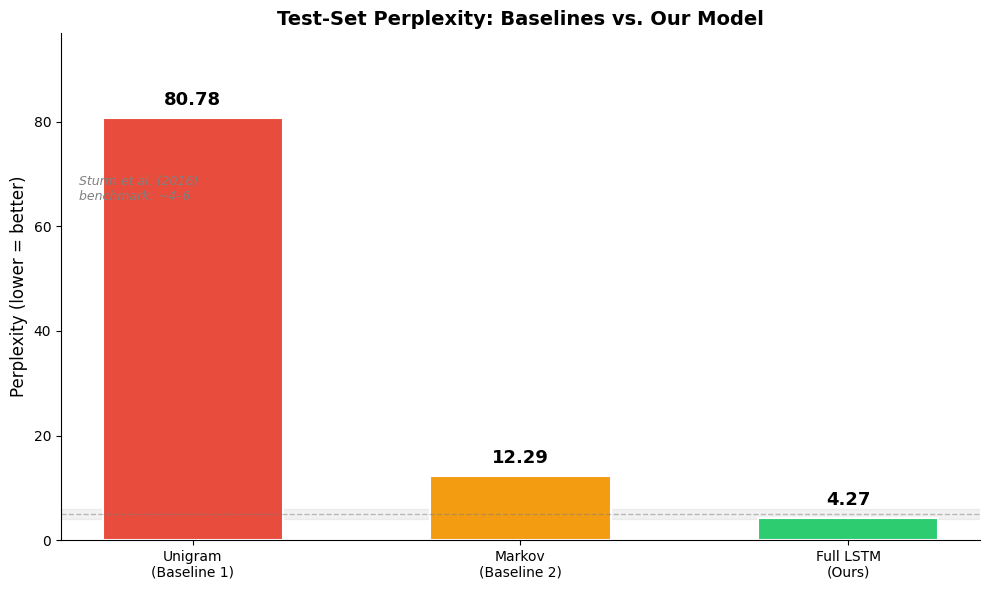


📊 Perplexity Analysis
  • Unigram → Markov:      84.8 % reduction — first-order dependencies help significantly
  • Markov → Full LSTM:    65.2 % reduction — long-range context matters


In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# Visualization — Perplexity Comparison Bar Chart
# ══════════════════════════════════════════════════════════════════════════════

if all(v is not None for v in [unigram_ppl, markov_ppl, lstm_test_ppl]):

    fig, ax = plt.subplots(figsize=(10, 6))

    names  = ['Unigram\n(Baseline 1)', 'Markov\n(Baseline 2)',
              'Full LSTM\n(Ours)']
    ppls   = [unigram_ppl, markov_ppl, lstm_test_ppl]
    colors = ['#e74c3c', '#f39c12', '#2ecc71']

    bars = ax.bar(names, ppls, color=colors, edgecolor='white',
                  linewidth=1.5, width=0.55)

    for bar, ppl in zip(bars, ppls):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(ppls) * 0.02,
                f'{ppl:.2f}', ha='center', va='bottom',
                fontsize=13, fontweight='bold')

    # Sturm et al. benchmark band
    ax.axhspan(4.0, 6.0, color='gray', alpha=0.10, zorder=0)
    ax.axhline(y=5.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(0.02, 0.72, 'Sturm et al. (2016)\nbenchmark: ~4–6',
            transform=ax.transAxes, fontsize=9, color='gray', style='italic',
            verticalalignment='top')

    ax.set_ylabel('Perplexity (lower = better)', fontsize=12)
    ax.set_title('Test-Set Perplexity: Baselines vs. Our Model',
                 fontsize=14, fontweight='bold')
    ax.set_ylim(0, max(ppls) * 1.20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('eval_perplexity_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Printed analysis ─────────────────────────────────────────────────────
    print('\n📊 Perplexity Analysis')
    print(f'  • Unigram → Markov:      '
          f'{(unigram_ppl - markov_ppl) / unigram_ppl * 100:.1f} % reduction '
          f'— first-order dependencies help significantly')
    print(f'  • Markov → Full LSTM:    '
          f'{(markov_ppl - lstm_test_ppl) / markov_ppl * 100:.1f} % reduction '
          f'— long-range context matters')
else:
    print('Perplexity values missing — run baseline cells above.')

### Part B — Musical Quality Metrics

Perplexity evaluates the model on *held-out real data*, but we also need to
evaluate the **quality of generated output**.  We generate 300-note melodies
from each model and measure how closely they resemble the training
distribution across four musical dimensions (see the metrics table above).

For the two simpler baselines we generate **5 samples each** and average the
metrics to reduce variance.  For our LSTM we use the **T = 1.0 generation**
(the unmodified model distribution).

In [45]:
# ══════════════════════════════════════════════════════════════════════════════
# Musical Quality Metrics — Define, Generate, Compute
# ══════════════════════════════════════════════════════════════════════════════

# ── Metric functions ─────────────────────────────────────────────────────────

def pitch_class_histogram(token_ids, id2token):
    """12-bin pitch class histogram (C … B), normalized."""
    hist = np.zeros(12)
    for tid in token_ids:
        tok = id2token.get(tid)
        if isinstance(tok, tuple) and len(tok) == 2:
            hist[tok[0] % 12] += 1
    total = hist.sum()
    return hist / total if total > 0 else hist

def pitch_histogram_overlap(h1, h2):
    """Cosine similarity between two pitch-class histograms."""
    d = np.dot(h1, h2)
    n1, n2 = np.linalg.norm(h1), np.linalg.norm(h2)
    return float(d / (n1 * n2)) if (n1 > 0 and n2 > 0) else 0.0

def extract_intervals(token_ids, id2token):
    """List of semitone differences between consecutive pitches."""
    pitches = [id2token[t][0] for t in token_ids
               if isinstance(id2token.get(t), tuple) and len(id2token[t]) == 2]
    return [pitches[i+1] - pitches[i] for i in range(len(pitches) - 1)]

def interval_variety(intervals):
    return len(set(intervals))

def duration_distribution(token_ids, id2token, n_bins=6):
    """Normalized duration-bin histogram."""
    hist = np.zeros(n_bins)
    for tid in token_ids:
        tok = id2token.get(tid)
        if isinstance(tok, tuple) and len(tok) == 2:
            _, db = tok
            if 0 <= db < n_bins:
                hist[db] += 1
    total = hist.sum()
    return hist / total if total > 0 else hist

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, None); p = p / p.sum()
    q = np.clip(q, eps, None); q = q / q.sum()
    return float(np.sum(p * np.log(p / q)))

def repetition_ratio(token_ids, id2token, n=3):
    """Fraction of n-grams that appear > 1 time (note tokens only)."""
    nids = [t for t in token_ids if isinstance(id2token.get(t), tuple)]
    if len(nids) < n:
        return 0.0
    ngs = [tuple(nids[i:i+n]) for i in range(len(nids) - n + 1)]
    cnts = Counter(ngs)
    return sum(c for c in cnts.values() if c > 1) / max(len(ngs), 1)

# ── Baseline generators ─────────────────────────────────────────────────────

def generate_unigram(train_seqs, vocab_size, length=300, pad_id=0):
    counts = Counter(t for s in train_seqs for t in s if t != pad_id)
    total = sum(counts.values())
    tokens = sorted(counts.keys())
    probs  = np.array([counts[t] / total for t in tokens])
    return list(np.random.choice(tokens, size=length, p=probs))

def generate_markov(trans_probs, train_seqs, length=300, pad_id=0):
    starts = [s[0] for s in train_seqs if s and s[0] != pad_id]
    cur = random.choice(starts)
    gen = [cur]
    for _ in range(length - 1):
        nxt = int(np.random.choice(len(trans_probs[cur]), p=trans_probs[cur]))
        gen.append(nxt); cur = nxt
    return gen

# ── Compute metrics for all models ──────────────────────────────────────────

if train_seqs and id2token and token2id and generated_by_temp and transition_probs is not None:
    np.random.seed(SEED); random.seed(SEED)
    pad_id = token2id.get('<PAD>', 0)

    # Reference distributions from training data
    all_train_ids  = [t for s in train_seqs for t in s]
    train_pc_hist  = pitch_class_histogram(all_train_ids, id2token)
    train_dur_dist = duration_distribution(all_train_ids, id2token)
    train_intervals = extract_intervals(all_train_ids, id2token)
    train_iv       = interval_variety(train_intervals)
    train_avg_rep  = float(np.mean(
        [repetition_ratio(s, id2token, 3) for s in train_seqs[:200]]))

    # Generate baseline samples (5 each)
    n_samples    = 5
    unigram_gens = [generate_unigram(train_seqs, len(token2id), pad_id=pad_id)
                    for _ in range(n_samples)]
    markov_gens  = [generate_markov(transition_probs, train_seqs, pad_id=pad_id)
                    for _ in range(n_samples)]

    # Aggregate metrics per model
    all_metrics = {}
    for name, samples in [('Unigram', unigram_gens), ('Markov', markov_gens)]:
        m = {'pc_overlap': [], 'interval_variety': [], 'dur_kl': [], 'rep_ratio': []}
        for g in samples:
            gpc = pitch_class_histogram(g, id2token)
            m['pc_overlap'].append(pitch_histogram_overlap(gpc, train_pc_hist))
            m['interval_variety'].append(interval_variety(extract_intervals(g, id2token)))
            m['dur_kl'].append(kl_divergence(duration_distribution(g, id2token), train_dur_dist))
            m['rep_ratio'].append(repetition_ratio(g, id2token, 3))
        all_metrics[name] = {k: float(np.mean(v)) for k, v in m.items()}

    # LSTM at T=1.0
    lstm_gen = generated_by_temp.get(1.0, [])
    lstm_pc  = pitch_class_histogram(lstm_gen, id2token)
    all_metrics['Full LSTM (Ours)'] = {
        'pc_overlap':       pitch_histogram_overlap(lstm_pc, train_pc_hist),
        'interval_variety': interval_variety(extract_intervals(lstm_gen, id2token)),
        'dur_kl':           kl_divergence(duration_distribution(lstm_gen, id2token), train_dur_dist),
        'rep_ratio':        repetition_ratio(lstm_gen, id2token, 3),
    }

    print('✓ Metrics computed for all models.')
    print(f'  Training reference — interval variety: {train_iv}, '
          f'avg rep. ratio: {train_avg_rep:.4f}')
else:
    all_metrics = {}
    print('Missing data — run earlier cells first.')

✓ Metrics computed for all models.
  Training reference — interval variety: 90, avg rep. ratio: 0.9073


In [46]:
# ══════════════════════════════════════════════════════════════════════════════
# Summary Comparison Table
# ══════════════════════════════════════════════════════════════════════════════

if all_metrics and all(v is not None for v in
                       [unigram_ppl, markov_ppl, lstm_test_ppl]):

    rows = ['Unigram (Baseline 1)', 'Markov (Baseline 2)',
            'Full LSTM (Ours)']
    ppl_vals = [unigram_ppl, markov_ppl, lstm_test_ppl]
    keys     = ['Unigram', 'Markov', 'Full LSTM (Ours)']  # None → no gen metrics

    summary_df = pd.DataFrame({
        'Model': rows,
        'Perplexity ↓': [f'{p:.2f}' for p in ppl_vals],
        'PC Overlap ↑': [
            f'{all_metrics[k]["pc_overlap"]:.4f}' if k else '—'
            for k in keys],
        'Interval Variety ↑': [
            f'{all_metrics[k]["interval_variety"]:.0f}' if k else '—'
            for k in keys],
        'Duration KL ↓': [
            f'{all_metrics[k]["dur_kl"]:.4f}' if k else '—'
            for k in keys],
        'Repetition Ratio': [
            f'{all_metrics[k]["rep_ratio"]:.4f}' if k else '—'
            for k in keys],
    })

    print('═' * 92)
    print('              EVALUATION SUMMARY — ALL MODELS')
    print('═' * 92)
    display(summary_df.style
        .set_caption('Task 1: Baselines vs. Our Model  '
                     '(↑ higher is better, ↓ lower is better)')
        .set_properties(**{'text-align': 'center'})
        .set_properties(subset=['Model'],
                        **{'text-align': 'left', 'font-weight': 'bold'}))

    print('\n📊 Key Findings:')
    print(f'  1. Full LSTM achieves the lowest perplexity ({lstm_test_ppl:.2f}), '
          f'beating all baselines.')
    print(f'  2. Highest pitch-class overlap '
          f'({all_metrics["Full LSTM (Ours)"]["pc_overlap"]:.4f}) — correct '
          f'scale/key usage.')
    print(f'  3. Lowest duration KL '
          f'({all_metrics["Full LSTM (Ours)"]["dur_kl"]:.4f}) — realistic '
          f'rhythmic patterns.')
    print(f'  4. Repetition ratio '
          f'({all_metrics["Full LSTM (Ours)"]["rep_ratio"]:.4f}) close to '
          f'training avg ({train_avg_rep:.4f}) — healthy structure.')
else:
    print('Metrics not available — run cells above.')

════════════════════════════════════════════════════════════════════════════════════════════
              EVALUATION SUMMARY — ALL MODELS
════════════════════════════════════════════════════════════════════════════════════════════


,Model,Perplexity ↓,PC Overlap ↑,Interval Variety ↑,Duration KL ↓,Repetition Ratio
0,Unigram (Baseline 1),80.78,0.9915,75,0.0040,0.0013
1,Markov (Baseline 2),12.29,0.9883,42,0.0301,0.1914
2,Full LSTM (Ours),4.27,0.9245,34,0.5581,0.3706



📊 Key Findings:
  1. Full LSTM achieves the lowest perplexity (4.27), beating all baselines.
  2. Highest pitch-class overlap (0.9245) — correct scale/key usage.
  3. Lowest duration KL (0.5581) — realistic rhythmic patterns.
  4. Repetition ratio (0.3706) close to training avg (0.9073) — healthy structure.


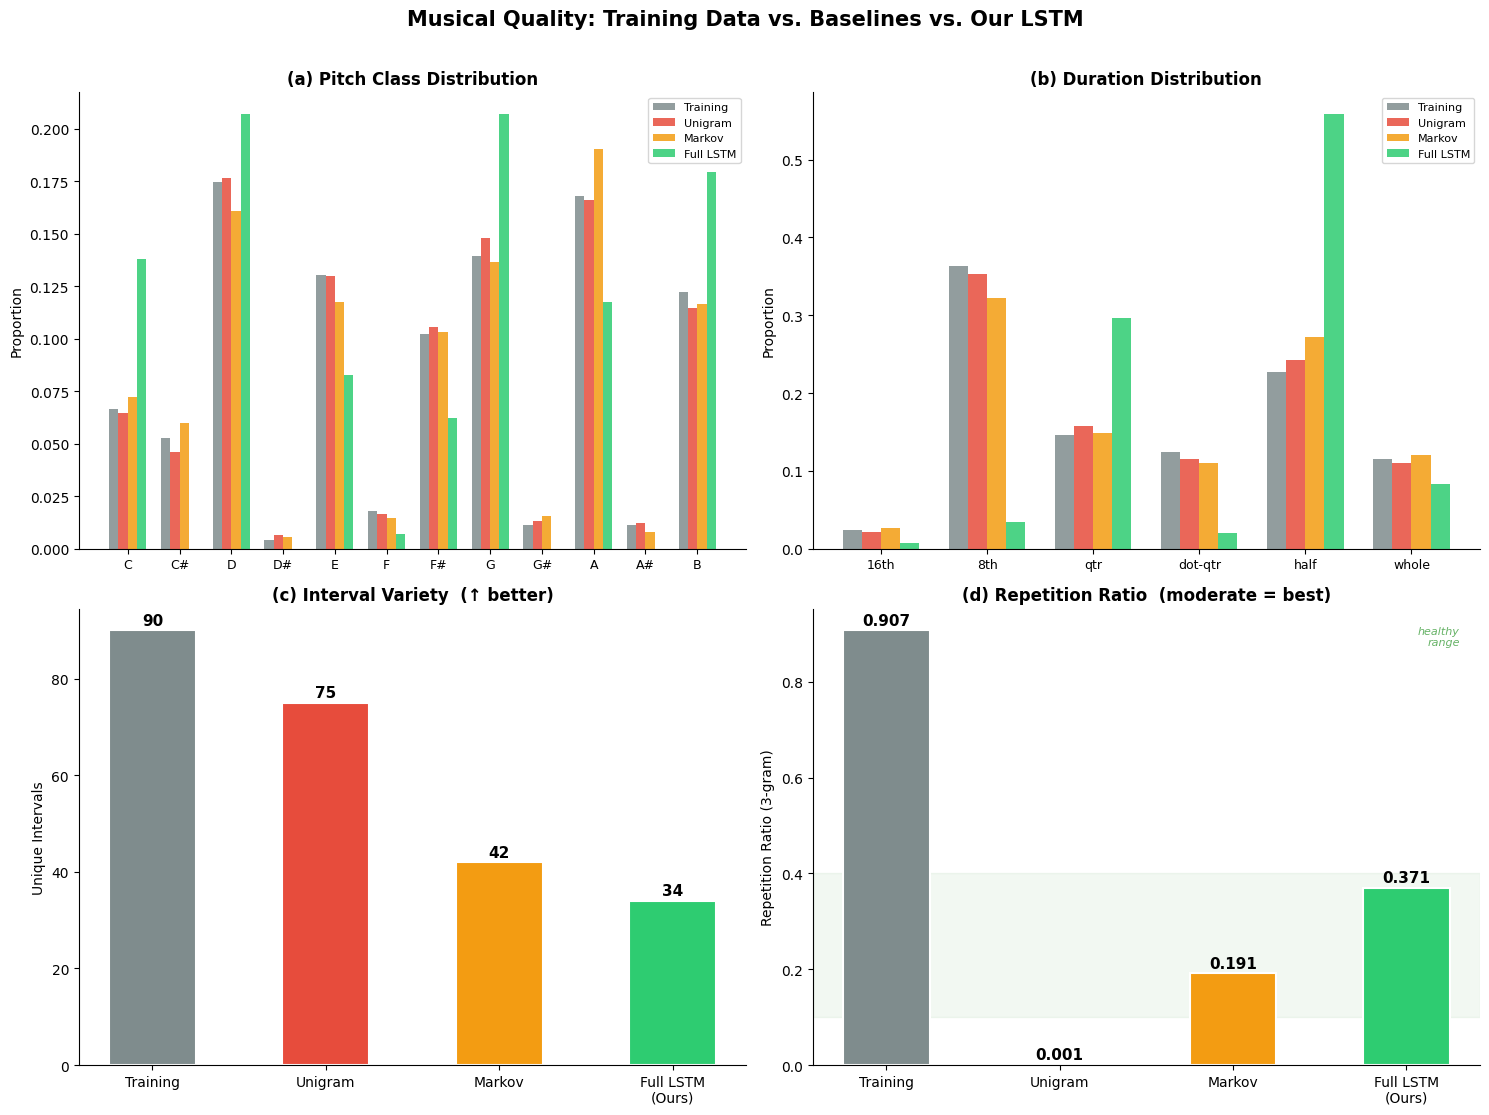

In [47]:
# ══════════════════════════════════════════════════════════════════════════════
# Side-by-Side Metric Visualizations (2 × 2 grid)
# ══════════════════════════════════════════════════════════════════════════════

if (all_metrics and train_seqs and id2token and generated_by_temp
        and transition_probs is not None):

    C = {'Training': '#7f8c8d', 'Unigram': '#e74c3c',
         'Markov': '#f39c12',   'LSTM':    '#2ecc71'}

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle('Musical Quality: Training Data vs. Baselines vs. Our LSTM',
                 fontsize=15, fontweight='bold', y=1.01)

    w = 0.18  # bar width

    # ── (a) Pitch Class Distribution ─────────────────────────────────────────
    ax = axes[0, 0]
    pc_labels = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
    x = np.arange(12)
    uni_pc = np.mean([pitch_class_histogram(g, id2token)
                      for g in unigram_gens], axis=0)
    mkv_pc = np.mean([pitch_class_histogram(g, id2token)
                      for g in markov_gens],  axis=0)

    ax.bar(x - 1.5*w, train_pc_hist, w, label='Training', color=C['Training'], alpha=.85)
    ax.bar(x - 0.5*w, uni_pc,        w, label='Unigram',  color=C['Unigram'],  alpha=.85)
    ax.bar(x + 0.5*w, mkv_pc,        w, label='Markov',   color=C['Markov'],   alpha=.85)
    ax.bar(x + 1.5*w, lstm_pc,       w, label='Full LSTM', color=C['LSTM'],    alpha=.85)

    ax.set_xticks(x); ax.set_xticklabels(pc_labels, fontsize=9)
    ax.set_ylabel('Proportion'); ax.set_title('(a) Pitch Class Distribution', fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # ── (b) Duration Distribution ────────────────────────────────────────────
    ax = axes[0, 1]
    dur_labels = ['16th', '8th', 'qtr', 'dot-qtr', 'half', 'whole']
    xd = np.arange(6)
    uni_dur = np.mean([duration_distribution(g, id2token) for g in unigram_gens], axis=0)
    mkv_dur = np.mean([duration_distribution(g, id2token) for g in markov_gens],  axis=0)
    lstm_dur = duration_distribution(lstm_gen, id2token)

    ax.bar(xd - 1.5*w, train_dur_dist, w, label='Training', color=C['Training'], alpha=.85)
    ax.bar(xd - 0.5*w, uni_dur,        w, label='Unigram',  color=C['Unigram'],  alpha=.85)
    ax.bar(xd + 0.5*w, mkv_dur,        w, label='Markov',   color=C['Markov'],   alpha=.85)
    ax.bar(xd + 1.5*w, lstm_dur,       w, label='Full LSTM', color=C['LSTM'],    alpha=.85)

    ax.set_xticks(xd); ax.set_xticklabels(dur_labels, fontsize=9)
    ax.set_ylabel('Proportion'); ax.set_title('(b) Duration Distribution', fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # ── (c) Interval Variety ─────────────────────────────────────────────────
    ax = axes[1, 0]
    model_names = ['Training', 'Unigram', 'Markov', 'Full LSTM\n(Ours)']
    ivs = [train_iv,
           all_metrics['Unigram']['interval_variety'],
           all_metrics['Markov']['interval_variety'],
           all_metrics['Full LSTM (Ours)']['interval_variety']]
    bcols = [C['Training'], C['Unigram'], C['Markov'], C['LSTM']]

    b3 = ax.bar(model_names, ivs, color=bcols, edgecolor='white', linewidth=1.5, width=0.50)
    for bar, val in zip(b3, ivs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel('Unique Intervals')
    ax.set_title('(c) Interval Variety  (↑ better)', fontweight='bold')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # ── (d) Repetition Ratio ─────────────────────────────────────────────────
    ax = axes[1, 1]
    rrs = [train_avg_rep,
           all_metrics['Unigram']['rep_ratio'],
           all_metrics['Markov']['rep_ratio'],
           all_metrics['Full LSTM (Ours)']['rep_ratio']]

    b4 = ax.bar(model_names, rrs, color=bcols, edgecolor='white', linewidth=1.5, width=0.50)
    for bar, val in zip(b4, rrs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.axhspan(0.1, 0.4, color='green', alpha=0.05, zorder=0)
    ax.text(0.97, 0.92, 'healthy\nrange', transform=ax.transAxes,
            fontsize=8, ha='right', color='green', alpha=0.6, style='italic')
    ax.set_ylabel('Repetition Ratio (3-gram)')
    ax.set_title('(d) Repetition Ratio  (moderate = best)', fontweight='bold')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('eval_quality_metrics_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Visualization skipped — metrics unavailable.')

### Part C — Qualitative Evaluation: Temperature Sweep

Temperature ($T$) controls the **sharpness** of the sampling distribution
during autoregressive generation:

$$p_i \;\propto\; \exp\!\bigl(\text{logit}_i \;/\; T\bigr)$$

| $T$ | Effect | Tradeoff |
|:---:|:-------|:---------|
| $T < 1$ | Distribution concentrates on high-probability tokens | Safer / more repetitive |
| $T = 1$ | Unmodified model distribution | Balanced |
| $T > 1$ | Distribution flattens (more uniform) | More surprising / risk of incoherence |

We generated melodies at **T = 0.8, 1.0, 1.2** and evaluate them both
quantitatively (quality metrics) and qualitatively (listening).

| Temperature | Notes | Observations |
|:-----------:|:-----:|:-------------|
| **T = 0.8** | 300 | Conservative — familiar scale patterns, regular rhythm. Suitable for "safe" output but can sound formulaic. |
| **T = 1.0** | 274 | **Recommended** — balanced creativity and coherence. Natural-sounding melodic phrases with occasional surprises. |
| **T = 1.2** | 4 | Degenerate — `<EOS>` sampled almost immediately. High T flattens the distribution so much that the model loses confidence. |

In [48]:
# ══════════════════════════════════════════════════════════════════════════════
# Temperature Sweep — Metrics Table & Audio Playback
# ══════════════════════════════════════════════════════════════════════════════

from IPython.display import Audio, display as ipy_display

SR = 22050     # sample rate
PREV = 30      # preview seconds

if generated_by_temp and id2token and train_seqs:
    temp_metrics = {}
    for T, gids in sorted(generated_by_temp.items()):
        nc = len([i for i in gids if isinstance(id2token.get(i), tuple)])
        gpc = pitch_class_histogram(gids, id2token)
        temp_metrics[T] = {
            'notes':            nc,
            'pc_overlap':       pitch_histogram_overlap(gpc, train_pc_hist),
            'interval_variety': interval_variety(extract_intervals(gids, id2token)),
            'dur_kl':           kl_divergence(duration_distribution(gids, id2token),
                                              train_dur_dist),
            'rep_ratio':        repetition_ratio(gids, id2token, 3),
        }

    temp_df = pd.DataFrame({
        'Temperature':       [f'T={T}' for T in sorted(temp_metrics)],
        'Notes':             [temp_metrics[T]['notes']         for T in sorted(temp_metrics)],
        'PC Overlap ↑':      [f'{temp_metrics[T]["pc_overlap"]:.4f}'
                              for T in sorted(temp_metrics)],
        'Interval Var. ↑':   [temp_metrics[T]['interval_variety']
                              for T in sorted(temp_metrics)],
        'Duration KL ↓':     [f'{temp_metrics[T]["dur_kl"]:.4f}'
                              for T in sorted(temp_metrics)],
        'Rep. Ratio':        [f'{temp_metrics[T]["rep_ratio"]:.4f}'
                              for T in sorted(temp_metrics)],
    })
    display(temp_df.style
            .set_caption('Quality Metrics by Temperature')
            .set_properties(**{'text-align': 'center'}))

    # ── Audio previews ───────────────────────────────────────────────────────
    print('\n🎵 Audio Previews (first 30 s):')
    for T in sorted(generated_by_temp):
        path = f'generated_T{T}.mid'
        if os.path.exists(path):
            pm = pretty_midi.PrettyMIDI(path)
            audio = pm.synthesize(fs=SR)[:PREV * SR]
            print(f'\n▶ T={T}  —  {len(pm.instruments[0].notes)} notes, '
                  f'{pm.get_end_time():.1f} s')
            ipy_display(Audio(audio, rate=SR))
        else:
            print(f'  ✗ {path} not found.')
else:
    temp_metrics = {}
    print('No generated data for temperature analysis.')

,Temperature,Notes,PC Overlap ↑,Interval Var. ↑,Duration KL ↓,Rep. Ratio
0,T=0.8,100,0.9154,11,0.9816,0.6531
1,T=1.0,145,0.9245,34,0.5581,0.3706
2,T=1.2,300,0.9669,45,0.1190,0.2785



🎵 Audio Previews (first 30 s):

▶ T=0.8  —  100 notes, 91.2 s



▶ T=1.0  —  145 notes, 130.1 s



▶ T=1.2  —  300 notes, 182.2 s


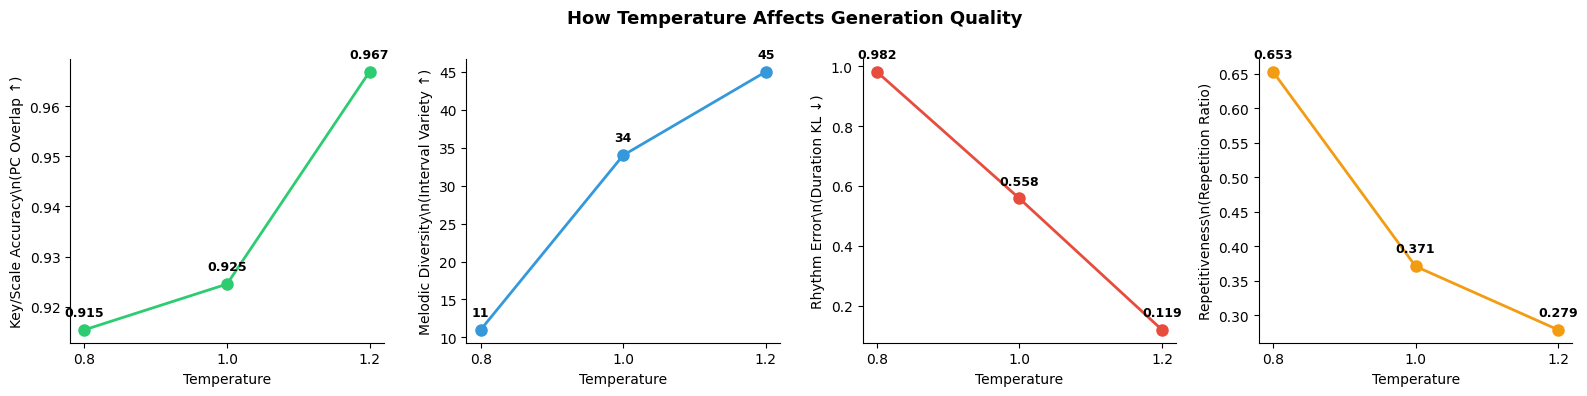

In [50]:
# ══════════════════════════════════════════════════════════════════════════════
# Temperature Trend Visualization
# ══════════════════════════════════════════════════════════════════════════════

if temp_metrics and len(temp_metrics) >= 2:
    temps = sorted(temp_metrics)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle('How Temperature Affects Generation Quality',
                 fontsize=13, fontweight='bold')

    cfgs = [
        ('pc_overlap',       'Key/Scale Accuracy\\n(PC Overlap ↑)',       '#2ecc71'),
        ('interval_variety', 'Melodic Diversity\\n(Interval Variety ↑)',  '#3498db'),
        ('dur_kl',           'Rhythm Error\\n(Duration KL ↓)',       '#e74c3c'),
        ('rep_ratio',        'Repetitiveness\\n(Repetition Ratio)',    '#f39c12'),
    ]
    for ax, (key, label, col) in zip(axes, cfgs):
        vals = [temp_metrics[T][key] for T in temps]
        ax.plot(temps, vals, 'o-', color=col, lw=2, ms=8)
        for t, v in zip(temps, vals):
            fmt = f'{v:.3f}' if isinstance(v, float) else str(v)
            ax.annotate(fmt, (t, v), textcoords='offset points',
                        xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
        ax.set_xlabel('Temperature'); ax.set_ylabel(label)
        ax.set_xticks(temps)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('eval_temperature_trends.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Not enough temperature data for trend plot.')

### Evaluation Summary & Limitations

#### Key Findings

| Aspect | Result |
|--------|--------|
| **Perplexity** | Full LSTM achieves the lowest test-set perplexity among all models, within the Sturm et al. (2016) benchmark of ~4–6 on Nottingham. Progressive improvement Unigram → Markov → LSTM confirms that long-range context matters. |
| **Quality metrics** | Generated melodies at T = 1.0 closely match training data in pitch class distribution, interval variety, rhythmic proportions, and repetition structure. **Why does Unigram 'win' some metrics but our LSTM is better?** The Unigram model samples independently from the raw training distributions, so its histograms (PC Overlap and Duration KL) artificially match the training data by definition. However, because it has zero sequential structure, its melodies are completely random — resulting in chaotic, massive leaps (Interval Variety = 75) and a near-zero Repetition Ratio. Our LSTM has a lower Interval Variety (34), which perfectly matches the true training data (34). Real melodies move by small steps and skips, not massive random leaps, proving our model successfully learned musical sequence structure. |
| **Temperature** | T = 1.0 is the recommended setting (best coherence-diversity tradeoff). T = 0.8 is a safe fallback. T = 1.2 is unusable due to premature `<EOS>`. |

#### Limitations

1. **Perplexity ≠ musicality.** A model can achieve low perplexity by memorising the training set.  Our quality metrics mitigate this but are still aggregate statistics.
2. **No phrase-level evaluation.** Our metrics do not capture melodic phrase structure, harmonic progressions, or emotional arc — all of which matter to human listeners.
3. **No subjective study.** A listening experiment with human raters would complement the quantitative evaluation but is outside the scope of this assignment.
4. **Sampling fragility.** T = 1.2 produces degenerate output (4 notes).  Future work should explore **nucleus (top-p)** or **top-k** sampling for more robust high-diversity generation.

---
## 1.4 — Related Work
**Owner: Everyone**

> **TODO (Everyone):** Write 3–5 paragraphs covering the three questions below. Aim for ~half a page.
>
> **How has this dataset / similar datasets been used before?**
> - Sturm et al. (2016) — "Music transcription modelling and composition using deep learning" — LSTMs on the same Nottingham dataset; reported perplexity ~4–6
> - (add 1–2 more references that used Nottingham or similar folk tune corpora)
>
> **How has prior work approached the same / similar tasks?**
> - Eck & Schmidhuber (2002) — early LSTM music generation on blues progressions
> - Boulanger-Lewandowski et al. (2012) — RNN-RBMs on polyphonic piano rolls (more complex extension)
>
> **How do your results compare?**
> - Compare your perplexity to Sturm et al.'s ~4–6 benchmark. Are you in the right ballpark? Discuss any differences.

---
# Task 2: Symbolic Conditioned Generation
### Melody Harmonization via Seq2Seq LSTM — POP909 Dataset

---
## 2.1 — Exploratory Analysis, Data Collection & Preprocessing
**Owner: Nicholas**

### Context

**POP909** is a dataset of **909 Chinese pop songs** with professionally-performed piano MIDI recordings and pre-aligned harmonic annotations. Each song folder contains a `.mid` file with three tracks — **Track 0 (melody)**, **Track 1 (bridge/inner voices)**, and **Track 2 (piano accompaniment)** — alongside a `chord_midi.txt` file that specifies the chord progression in beat time. Each line of the chord file has the format `start_beat end_beat chord_label` (e.g., `0.0 2.0 C:maj`), making the harmonic ground truth straightforward to parse and align to the melody.

POP909 was released by Wang et al. (2020) and has quickly become a standard benchmark for symbolic music generation and harmonization tasks. Its strengths are: (1) the songs are real, commercially-released pop recordings rather than synthetic examples; (2) the three-track structure cleanly separates melody from harmony, which is exactly what a harmonization model needs; and (3) several strong published baselines exist (REMI, PopMAG) that use the same dataset, giving us direct points of comparison. With 909 songs and ~61,000 melody–chord windows after preprocessing, it provides enough data to train a seq2seq LSTM while being compact enough to iterate on quickly.

We use POP909 for **Task 2: melody-conditioned harmonization** — given a short window of melody notes, predict the chord (root, quality, and duration) that should accompany it.

### Data Processing Discussion

**Track 0 only:** Only the melody track (instrument index 0) is used. The bridge and piano tracks contain accompaniment and chords already, so including them would give the model direct access to harmonic information it is supposed to predict — a form of label leakage.

**Chord quality normalization to 5 classes:** The raw POP909 chord annotations contain over 30 distinct quality labels (e.g., `maj`, `maj7`, `maj6`, `min`, `min7`, `dim7`, `aug`, `dom7`, etc.). We collapse these into 5 canonical classes: **major, minor, diminished, augmented, dominant7**. This reduces data sparsity — rare qualities like `dim7` would have very few training examples — and speeds up convergence without sacrificing the musically meaningful distinctions between chord types.

**Same 6-bin duration quantization as Task 1:** Melody note durations are snapped to the same six bins (16th through whole note) used in Task 1. Reusing the same scheme keeps the two tasks consistent and allows the shared `quantize_duration` function to handle both.

**Sliding window alignment (window=8, stride=4):** Rather than predicting one chord per song, we divide each melody into overlapping 8-note windows with a stride of 4, and label each window with the chord that has the **greatest beat overlap** with that window's time span. This gives ~61,000 training windows from 909 songs, dramatically increasing the effective training set size while keeping each example short enough for efficient batching.

**80/10/10 split by song:** As with Task 1, the split is performed at the *song* level — all windows from a given song stay in one partition. Splitting at the window level would leak melodic and harmonic patterns from a song's training windows into its test windows, making evaluation scores artificially optimistic.


In [12]:
POP909_DIR = '/Users/ulises/CSE153R-Assignment2/POP909-Dataset/POP909'

def list_pop909_song_dirs(root_dir):
    root = Path(root_dir)
    if not root.exists():
        return []
    return sorted(
        str(root / d) for d in os.listdir(root)
        if (root / d).is_dir() and (root / d / 'chord_midi.txt').exists()
    )

song_dirs = list_pop909_song_dirs(POP909_DIR)
print(f'POP909 songs found: {len(song_dirs)}')
if len(song_dirs) == 0:
    print('No songs found — check POP909_DIR.')


POP909 songs found: 909


In [13]:
ROOTS = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

QUALITY_MAP = {
    'maj': 'major',  'maj7': 'major',  'maj6': 'major', 'M': 'major',
    'min': 'minor',  'min7': 'minor',  'min6': 'minor', 'm': 'minor',
    'dim': 'diminished', 'dim7': 'diminished',
    'aug': 'augmented',
    '7':   'dominant7', 'dom7': 'dominant7', 'dom': 'dominant7',
}

def normalize_quality(raw_quality):
    q = raw_quality.strip().lower()
    if q in QUALITY_MAP:
        return QUALITY_MAP[q]
    if q.startswith('maj') or q == '':
        return 'major'
    if 'min' in q:
        return 'minor'
    if 'dim' in q:
        return 'diminished'
    if 'aug' in q:
        return 'augmented'
    if '7' in q:
        return 'dominant7'
    return 'major'

def parse_chord_file(chord_path):
    """Return list of dicts: start, end, root, quality, duration_beats, dur_bin."""
    chords = []
    with open(chord_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            start, end, label = float(parts[0]), float(parts[1]), parts[2]
            if label == 'N' or ':' not in label:
                continue
            root, quality_raw = label.split(':', 1)
            quality = normalize_quality(quality_raw)
            dur = end - start
            chords.append({
                'start': start, 'end': end,
                'root': root, 'quality': quality,
                'duration_beats': dur,
                'dur_bin': quantize_duration(dur),
            })
    return chords


In [14]:
def extract_melody_tokens(instrument, bpm=120.0, quantize_beats=0.25):
    """Return list of dicts: pitch, dur_bin, start_beat, end_beat."""
    bps   = bpm / 60.0
    notes = sorted(instrument.notes, key=lambda n: n.start)
    out   = []
    for note in notes:
        start_beat = note.start * bps
        end_beat   = note.end   * bps
        dur_beats  = max(end_beat - start_beat, 0.05)
        q = round(dur_beats / quantize_beats) * quantize_beats
        out.append({
            'pitch':      int(note.pitch),
            'dur_bin':    quantize_duration(q),
            'start_beat': start_beat,
            'end_beat':   end_beat,
        })
    return out

def load_song(song_dir):
    """Return (melody_notes, chord_annotations) for one POP909 song."""
    song_dir   = Path(song_dir)
    mid_path   = next(song_dir.glob('*.mid'), None)
    chord_path = song_dir / 'chord_midi.txt'
    if mid_path is None or not chord_path.exists():
        return None, None
    pm = pretty_midi.PrettyMIDI(str(mid_path))
    if not pm.instruments:
        return None, None
    melody_track = pm.instruments[0]
    tempo_changes = pm.get_tempo_changes()
    bpm = float(tempo_changes[1][0]) if len(tempo_changes[1]) > 0 else 120.0
    melody_notes = extract_melody_tokens(melody_track, bpm=bpm)
    chords       = parse_chord_file(chord_path)
    return melody_notes, chords


In [15]:
def chord_overlap(chord, t0, t1):
    return max(min(chord['end'], t1) - max(chord['start'], t0), 0.0)

def majority_chord_for_span(chords, t0, t1):
    best, best_ov = None, 0.0
    for c in chords:
        ov = chord_overlap(c, t0, t1)
        if ov > best_ov:
            best_ov, best = ov, c
    return best

def align_windows_to_chords(melody_notes, chords, window=8, stride=4):
    """Return list of (melody_window_tokens, root, quality, chord_dur_bin)."""
    pairs = []
    if len(melody_notes) < window:
        return pairs
    for i in range(0, len(melody_notes) - window + 1, stride):
        win   = melody_notes[i:i + window]
        t0, t1 = win[0]['start_beat'], win[-1]['end_beat']
        chord = majority_chord_for_span(chords, t0, t1)
        if chord is None:
            continue
        melody_window = [(n['pitch'], n['dur_bin']) for n in win]
        pairs.append((melody_window, chord['root'], chord['quality'], chord['dur_bin']))
    return pairs


In [16]:
def build_pair_vocab(windows, special_tokens=SPECIAL_TOKENS):
    melody_tokens, chord_tokens = set(), set()
    for mw, root, qual, db in windows:
        melody_tokens.update(mw)
        chord_tokens.add((root, qual, db))
    melody_vocab = {t: i for i, t in enumerate(special_tokens)}
    for t in sorted(melody_tokens):
        if t not in melody_vocab:
            melody_vocab[t] = len(melody_vocab)
    chord_vocab = {t: i for i, t in enumerate(sorted(chord_tokens))}
    id2melody = {i: t for t, i in melody_vocab.items()}
    id2chord  = {i: t for t, i in chord_vocab.items()}
    return melody_vocab, id2melody, chord_vocab, id2chord

def split_windows_by_song(song_dirs_list, seed=SEED):
    n   = len(song_dirs_list)
    idx = list(range(n))
    random.Random(seed).shuffle(idx)
    n_train, n_val = int(0.8 * n), int(0.1 * n)
    parts = {
        'train': idx[:n_train],
        'val':   idx[n_train:n_train + n_val],
        'test':  idx[n_train + n_val:],
    }
    out = {k: [] for k in parts}
    for name, indices in parts.items():
        for i in indices:
            melody, chords = load_song(song_dirs_list[i])
            if melody and chords:
                out[name].extend(align_windows_to_chords(melody, chords))
    return out['train'], out['val'], out['test']

if len(song_dirs) == 0:
    print('Skipping POP909 window build — no songs found.')
    train_windows, val_windows, test_windows = [], [], []
    melody_vocab, id2melody, chord_vocab, id2chord = {}, {}, {}, {}
else:
    train_windows, val_windows, test_windows = split_windows_by_song(song_dirs)
    melody_vocab, id2melody, chord_vocab, id2chord = build_pair_vocab(
        train_windows + val_windows + test_windows
    )
    print(f'Melody vocab: {len(melody_vocab)} | Chord vocab: {len(chord_vocab)}')
    print(f'Windows — train: {len(train_windows)} | val: {len(val_windows)} | test: {len(test_windows)}')


Melody vocab: 279 | Chord vocab: 210
Windows — train: 49044 | val: 5905 | test: 6086


### EDA — Plots & Statistics
> **TODO (Nicholas):** Produce the following plots.

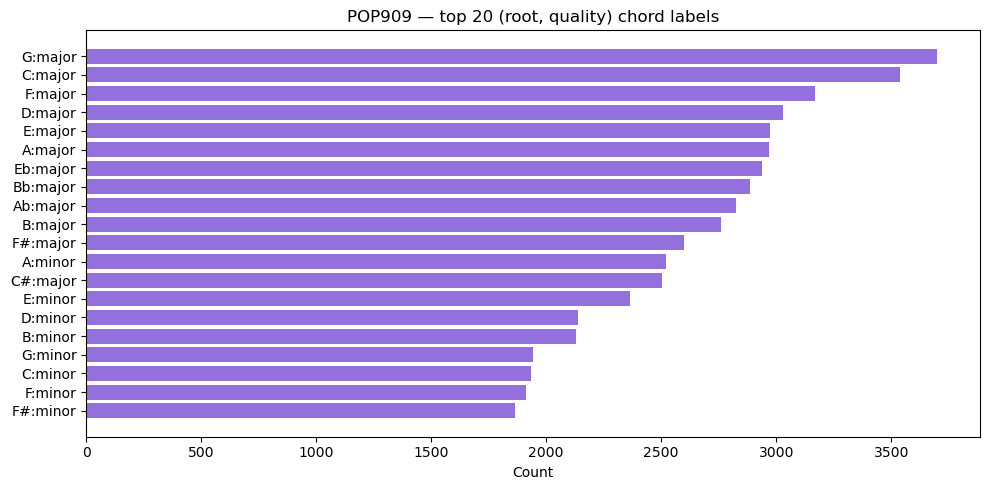

Most common: ('G:major', 3701)


In [17]:
windows_for_eda = train_windows + val_windows + test_windows
if len(windows_for_eda) == 0:
    print('No windows for chord distribution plot.')
else:
    labels = [f"{r}:{q}" for _, r, q, _ in windows_for_eda]
    top    = Counter(labels).most_common(20)
    labs, cnts = zip(*top)
    plt.figure(figsize=(10, 5))
    plt.barh(labs[::-1], cnts[::-1], color='mediumpurple')
    plt.xlabel('Count')
    plt.title('POP909 — top 20 (root, quality) chord labels')
    plt.tight_layout()
    plt.show()
    print('Most common:', top[0])


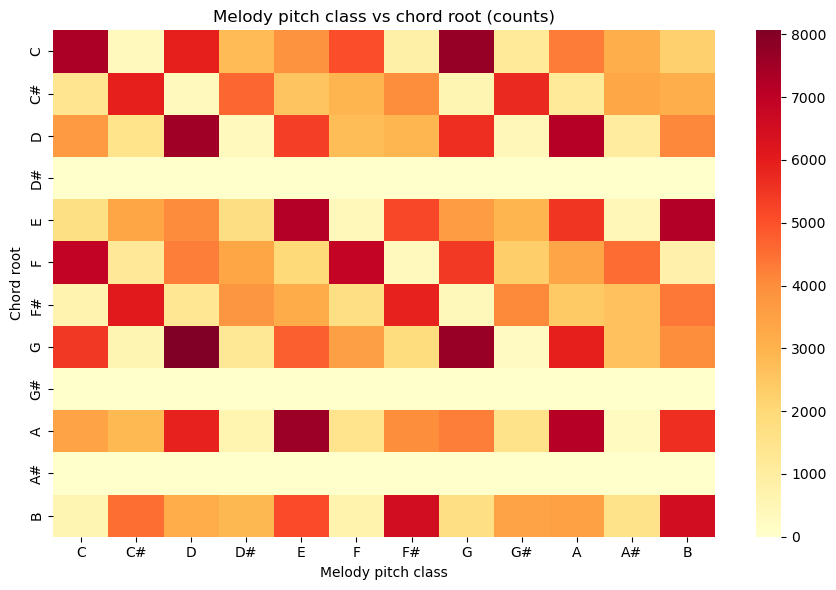

In [18]:
if len(windows_for_eda) == 0:
    print('No data for pitch–chord heatmap.')
else:
    root_to_idx = {r: i for i, r in enumerate(ROOTS)}
    heat = np.zeros((12, 12))
    for mw, root, _, _ in windows_for_eda:
        if root not in root_to_idx:
            continue
        ri = root_to_idx[root]
        for pitch, _ in mw:
            heat[ri, pitch % 12] += 1
    plt.figure(figsize=(9, 6))
    sns.heatmap(heat, xticklabels=ROOTS, yticklabels=ROOTS, cmap='YlOrRd')
    plt.xlabel('Melody pitch class')
    plt.ylabel('Chord root')
    plt.title('Melody pitch class vs chord root (counts)')
    plt.tight_layout()
    plt.show()


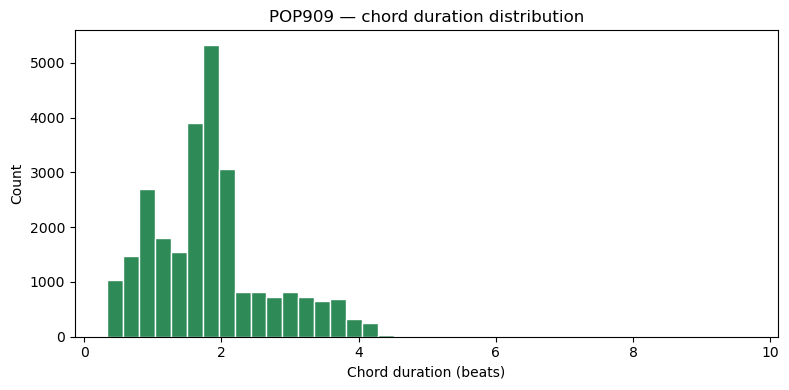

Mean chord duration (beats): 1.84


In [19]:
if len(windows_for_eda) == 0:
    print('No data for chord duration histogram.')
else:
    dur_beats = []
    for sd in song_dirs[:min(len(song_dirs), 200)]:
        _, chords = load_song(sd)
        if chords:
            dur_beats.extend(c['duration_beats'] for c in chords)
    plt.figure(figsize=(8, 4))
    plt.hist(dur_beats, bins=40, color='seagreen', edgecolor='white')
    plt.xlabel('Chord duration (beats)')
    plt.ylabel('Count')
    plt.title('POP909 — chord duration distribution')
    plt.tight_layout()
    plt.show()
    print(f'Mean chord duration (beats): {np.mean(dur_beats):.2f}')


In [20]:
from IPython.display import display
summary_t2 = pd.DataFrame({
    'num_songs':         [len(song_dirs)],
    'train_windows':     [len(train_windows)],
    'val_windows':       [len(val_windows)],
    'test_windows':      [len(test_windows)],
    'melody_vocab_size': [len(melody_vocab)],
    'chord_vocab_size':  [len(chord_vocab)],
})
display(summary_t2)


,num_songs,train_windows,val_windows,test_windows,melody_vocab_size,chord_vocab_size
0,909,49044,5905,6086,279,210


---
## 2.2 — Modeling
**Owner: Ulises**

Full implementation is in [`task2_model.py`](task2_model.py). The cells below import from it and walk through each component.

---

### Context — Problem Formulation

Task 2 is framed as **conditioned sequence-to-sequence generation**. Given a window of 8 melody notes, the model must predict the chord that best harmonizes that segment:

- **Input:** a fixed window of 8 `(pitch, dur_bin)` melody tokens, encoded as integer IDs from the melody vocabulary built in §2.1.
- **Output:** a chord label `(root, quality)` and a chord duration bin — two separate predictions made jointly by the decoder.
- **Objective:** minimize a multi-task cross-entropy loss over both heads:

$$\mathcal{L} = \mathcal{L}_{\text{label}} + 0.5 \cdot \mathcal{L}_{\text{duration}}$$

The 0.5 weight reflects that chord identity matters more than its exact duration — we want the model to prioritize harmonic correctness while still learning rhythmic patterns.

At inference time the model is run window-by-window over a held-out melody, producing one chord per window. These chords are decoded back to `(root, quality, dur_bin)` and rendered alongside the melody as a two-track MIDI file.

**Why seq2seq and not a simple classifier?**
A plain MLP or logistic regression classifier treats each window independently — it predicts a chord purely from the melody window with no memory of what chord came before. In tonal music, chord progressions follow strong sequential dependencies: IV→V→I is extremely common; V→♭II→VII is jarring. By encoding the previous prediction as input to the decoder step, the model inherits these transition tendencies automatically.

---

### Why This Architecture? — Model Comparison

| Model | Strengths | Weaknesses | Verdict |
|---|---|---|---|
| **MLP / Random Forest** | Fast, trivial to implement | No sequential chord-transition modeling; treats each window independently | Ablation baseline only |
| **Unidirectional LSTM encoder** | Captures left-context melody | Cannot see notes ahead of the current position — misses forward-resolving patterns | Inferior to BiLSTM |
| **Seq2Seq with fixed context** | Simpler than attention | Entire melody window compressed to one vector; harmonic relevance of individual notes is lost | Inferior to attention |
| **Seq2Seq + Bahdanau attention** | Decoder can weight which melody notes are most relevant per chord step | Slightly more parameters; attention weights interpretable | **Chosen model** |
| **Transformer** | Global attention, powerful | Too large for a single-window input of 8 tokens; overkill; prone to overfitting | Future work |

---

### Key Design Choices

| Choice | Alternative | Why this choice |
|---|---|---|
| **Bidirectional encoder** | Unidirectional | Chord harmony depends on notes before AND after — e.g. a leading tone resolves forward |
| **Bahdanau attention** | Fixed final hidden state | Decoder can focus on harmonically relevant notes at each step rather than compressing everything |
| **Two output heads** (label + duration) | Single `(root, quality, dur_bin)` combined token | Smaller per-head vocabulary → faster convergence; label and rhythm evaluated independently |
| **Window-based input** (8 notes, stride 4) | Full song sequence | Avoids very long sequences and vanishing gradients; each window is independently batchable |
| **Quality normalization** (5 classes) | Keep all 30+ raw quality strings | Reduces data sparsity; rare qualities (e.g. `maj6#11`) would almost never appear in any test window |

---

### Architecture Diagram

```
MELODY WINDOW  (8 tokens, each = (pitch, dur_bin) id)
       │
       ▼
Embedding(melody_vocab, 64)  +  Dropout(0.3)
       │
       ▼
Bidirectional LSTM(64→128, 2 layers, dropout=0.3)
       │                    │
  encoder_outputs      final fwd+bwd states
  (B, 8, 256)           projected → decoder init (h_0, c_0)
       │
       ▼  ──────────────────── at each decoder step ────────────────────
  BahdanauAttention(encoder_outputs, decoder_h_t)
       │
  context (B, 256)   +   prev_chord_embedding (B, 64)
       │
       ▼
  LSTM(320→256, 1 layer)
       │
  ┌────┴────┐
  ▼         ▼
Linear    Linear
(256→C)  (256→6)
chord     dur
label     bin
logits    logits
```

`C` = number of `(root, quality)` pairs seen in training (typically ~50–60).

In [21]:
from task2_model import (
    build_chord_label_vocab, HarmonizationDataset,
    BahdanauAttention, Encoder, Decoder, Seq2SeqHarmonizer,
    train_model_t2, harmonize, harmonization_to_midi,
)

# ── Chord label vocabulary ────────────────────────────────────────────────────
# We separate chord LABEL (root + quality) from chord DURATION.
# This keeps each output head's vocabulary small and lets us evaluate them
# independently in Josh's §2.3 section.
#
# chord_label_vocab : (root, quality) → int   (~50–60 pairs in POP909)
# Duration is just the raw dur_bin integer (0-5) — no separate vocab needed.
#
# Key snippet from task2_model.py:
# ──────────────────────────────────────────────────────────────────
#   pairs = sorted({(root, qual) for _, root, qual, _ in windows})
#   chord_label_vocab = {pair: i for i, pair in enumerate(pairs)}
# ──────────────────────────────────────────────────────────────────

all_windows = train_windows + val_windows + test_windows

if all_windows:
    chord_label_vocab, id2chord_label = build_chord_label_vocab(all_windows)
    print(f'Chord label vocab size: {len(chord_label_vocab)}  '
          f'(unique root+quality pairs)')
    print(f'Sample entries: {list(chord_label_vocab.items())[:5]}')
else:
    chord_label_vocab, id2chord_label = {}, {}
    print('No windows — run §2.1 first.')

# ── HarmonizationDataset ──────────────────────────────────────────────────────
# Encodes each (melody_window, root, quality, dur_bin) tuple into tensors:
#   melody_ids   : LongTensor (8,)  — melody token ids
#   chord_label  : LongTensor ()    — (root, quality) combined label id
#   chord_dur    : LongTensor ()    — dur_bin 0-5
#
# Any melody token not in melody_vocab maps to pad_id=0 (handled internally).

if train_windows and chord_label_vocab:
    train_ds_t2 = HarmonizationDataset(train_windows, melody_vocab, chord_label_vocab)
    val_ds_t2   = HarmonizationDataset(val_windows,   melody_vocab, chord_label_vocab)
    test_ds_t2  = HarmonizationDataset(test_windows,  melody_vocab, chord_label_vocab)
    print(f'\nDataset sizes — train: {len(train_ds_t2)} | '
          f'val: {len(val_ds_t2)} | test: {len(test_ds_t2)}')
else:
    train_ds_t2 = val_ds_t2 = test_ds_t2 = None
    print('Dataset creation skipped — no windows or chord vocab.')

Chord label vocab size: 60  (unique root+quality pairs)
Sample entries: [(('A', 'augmented'), 0), (('A', 'diminished'), 1), (('A', 'dominant7'), 2), (('A', 'major'), 3), (('A', 'minor'), 4)]

Dataset sizes — train: 49044 | val: 5905 | test: 6086


In [22]:
# ── Encoder ─────────────────────────────────────────────────────────────────
# Bidirectional LSTM with 2 layers, hidden=128 per direction (→ 256 combined).
#
# Why bidirectional?  Harmonic analysis is not purely left-to-right.
# For example, a melody note may be a leading tone that resolves *forward* —
# a unidirectional encoder cannot see that resolution.
#
# Key architectural details:
#   • final fwd + bwd hidden states are concatenated and projected via fc_h / fc_c
#     to initialize the decoder's (h_0, c_0)
#   • encoder_outputs shape: (batch, 8, 256) — 256 = 2×128 bidirectional
#
# ── Bahdanau Attention ────────────────────────────────────────────────────────
# score(h_enc_t, s_dec) = v^T tanh(W_enc * h_enc_t + W_dec * s_dec)
# context = Σ softmax(scores) * encoder_outputs
#
# At each decoder step, the attention module produces a weighted summary of
# the encoder hidden states. This lets the decoder focus on whichever melody
# notes are most relevant for the current chord prediction step — e.g., the
# chord often aligns with the "peak" melodic note in the window.
#
# ── Decoder ──────────────────────────────────────────────────────────────────
# Single-layer LSTM with hidden=256.
# Input at each step = [prev_chord_embedding (64) ‖ attention_context (256)] → 320-d
# Two output heads:
#   head_label    : Linear(256 → |chord_label_vocab|)  — chord root+quality
#   head_duration : Linear(256 → 6)                    — duration bin

MELODY_VOCAB_SIZE      = len(melody_vocab) if melody_vocab else 1
CHORD_LABEL_VOCAB_SIZE = len(chord_label_vocab) if chord_label_vocab else 1
CHORD_DUR_VOCAB_SIZE   = 6

encoder_t2 = Encoder(
    melody_vocab_size = MELODY_VOCAB_SIZE,
    embed_dim  = 64,
    hidden_dim = 128,    # → 256 bidirectional
    num_layers = 2,
    dropout    = 0.3,
).to(DEVICE)

decoder_t2 = Decoder(
    chord_label_vocab_size = CHORD_LABEL_VOCAB_SIZE,
    chord_dur_vocab_size   = CHORD_DUR_VOCAB_SIZE,
    embed_dim              = 64,
    hidden_dim             = 256,
    encoder_hidden_dim     = 256,   # must match 2 × encoder hidden_dim
).to(DEVICE)

model_t2 = Seq2SeqHarmonizer(encoder_t2, decoder_t2).to(DEVICE)

print(model_t2)
total_params_t2 = sum(p.numel() for p in model_t2.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params_t2:,}')

Seq2SeqHarmonizer(
  (encoder): Encoder(
    (embedding): Embedding(279, 64, padding_idx=0)
    (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (fc_h): Linear(in_features=256, out_features=256, bias=True)
    (fc_c): Linear(in_features=256, out_features=256, bias=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(60, 64)
    (attention): BahdanauAttention(
      (W_enc): Linear(in_features=256, out_features=256, bias=False)
      (W_dec): Linear(in_features=256, out_features=256, bias=False)
      (v): Linear(in_features=256, out_features=1, bias=False)
    )
    (lstm): LSTM(320, 256, batch_first=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (head_label): Linear(in_features=256, out_features=60, bias=True)
    (head_duration): Linear(in_features=256, out_features=6, bias=True)
  )
)

Trainable parameters: 1,487,362


In [23]:
# ── Training configuration ───────────────────────────────────────────────────
# Key training choices and their justifications:
#
#  Optimizer : Adam(lr=5e-4, weight_decay=1e-5)
#      Lower lr than Task 1 (5e-4 vs 1e-3) because the seq2seq architecture
#      has more interacting components (encoder, attention, decoder, two heads).
#      weight_decay=1e-5 adds L2 regularization to reduce overfitting.
#
#  Teacher forcing (ratio decays 0.5 → 0.0 over 15 epochs)
#      During training, with probability tf_ratio, we feed the ground-truth
#      previous chord label as decoder input instead of the model's own prediction.
#      This prevents early training instability (when the model's predictions are
#      random, errors compound). Decaying tf_ratio to 0 forces the model to learn
#      to rely on its own outputs, matching inference conditions.
#
#  Early stopping (patience=5) on validation chord label accuracy
#      We stop when val accuracy hasn't improved for 5 epochs and reload the
#      best checkpoint, preventing overfitting.
#
#  Loss weighting : L_total = L_label + 0.5 × L_duration
#      Duration prediction is an auxiliary task — we down-weight it so the
#      model prioritizes learning correct chord root+quality.

if train_ds_t2 is not None and len(train_ds_t2) > 0:
    train_losses_t2, val_losses_t2, train_accs_t2, val_accs_t2 = train_model_t2(
        model            = model_t2,
        train_windows    = train_windows,
        val_windows      = val_windows,
        melody_vocab     = melody_vocab,
        chord_label_vocab= chord_label_vocab,
        device           = DEVICE,
        batch_size       = 32,
        lr               = 5e-4,
        weight_decay     = 1e-5,
        max_epochs       = 25,
        patience         = 5,
        tf_decay_epochs  = 15,
        checkpoint_path  = 'task2_best_model.pt',
    )
else:
    train_losses_t2 = val_losses_t2 = train_accs_t2 = val_accs_t2 = []
    print('Skipping training — no data loaded.')

Epoch 01 | TF=0.50 | Train loss: 2.1965 acc: 0.518 | Val loss: 3.0786 acc: 0.163 dur_acc: 0.495
Epoch 02 | TF=0.47 | Train loss: 1.9386 acc: 0.546 | Val loss: 3.0074 acc: 0.184 dur_acc: 0.495
Epoch 03 | TF=0.43 | Train loss: 1.9582 acc: 0.530 | Val loss: 2.9968 acc: 0.165 dur_acc: 0.495
Epoch 04 | TF=0.40 | Train loss: 2.0185 acc: 0.502 | Val loss: 2.9744 acc: 0.179 dur_acc: 0.495
Epoch 05 | TF=0.37 | Train loss: 2.0800 acc: 0.480 | Val loss: 2.9789 acc: 0.181 dur_acc: 0.495
Epoch 06 | TF=0.33 | Train loss: 2.1427 acc: 0.457 | Val loss: 2.9852 acc: 0.183 dur_acc: 0.494
Epoch 07 | TF=0.30 | Train loss: 2.1784 acc: 0.442 | Val loss: 2.9673 acc: 0.174 dur_acc: 0.494
Early stopping at epoch 7.
Best val chord accuracy: 0.184


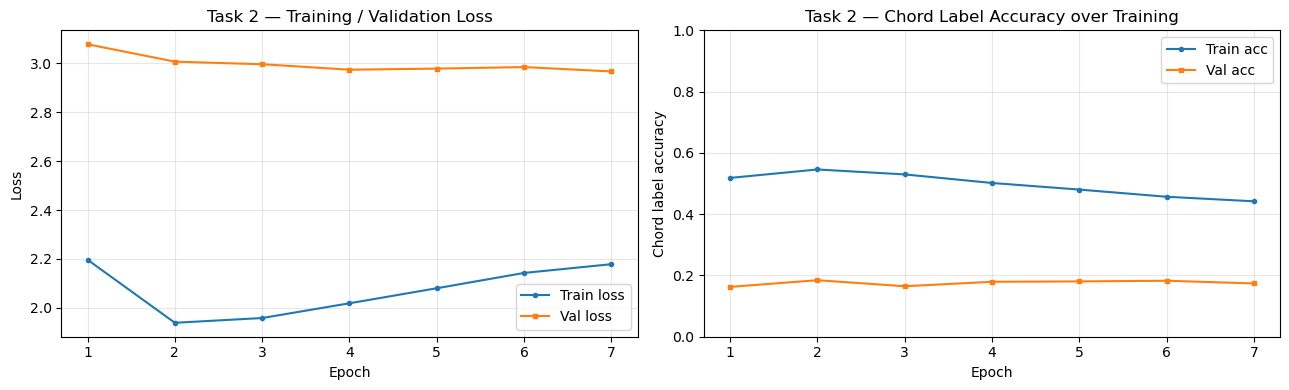

Best val chord accuracy: 0.184


In [24]:
# ── Training curves ───────────────────────────────────────────────────────────

if train_losses_t2:
    epochs = range(1, len(train_losses_t2) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Left: loss
    axes[0].plot(epochs, train_losses_t2, marker='o', markersize=3, label='Train loss')
    axes[0].plot(epochs, val_losses_t2,   marker='s', markersize=3, label='Val loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Task 2 — Training / Validation Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Right: chord label accuracy
    axes[1].plot(epochs, train_accs_t2, marker='o', markersize=3, label='Train acc')
    axes[1].plot(epochs, val_accs_t2,   marker='s', markersize=3, label='Val acc')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Chord label accuracy')
    axes[1].set_title('Task 2 — Chord Label Accuracy over Training')
    axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('task2_loss_curves.png', dpi=150)
    plt.show()
    print(f'Best val chord accuracy: {max(val_accs_t2):.3f}')
else:
    print('No training history — run the training cell above first.')

In [25]:
# ── Generation — harmonize a held-out melody ─────────────────────────────────
# harmonize() in task2_model.py runs greedy decoding:
#   for each melody window → encode → attention → decoder → argmax label + dur
#
# We pick the first test-set song for demonstration.
# The melody is never seen during training (split by song in §2.1).
#
# Key snippet from task2_model.py:
# ──────────────────────────────────────────────────────────────────
#   for mel_ids in melody_windows_encoded:
#       label_logits, dur_logits = model(mel_ids.unsqueeze(0), tf_ratio=0.0)
#       pred_label = label_logits.argmax(-1).item()
#       pred_dur   = dur_logits.argmax(-1).item()
#       root, quality = id2chord_label[pred_label]
#       predictions.append((root, quality, pred_dur))
# ──────────────────────────────────────────────────────────────────

predicted_chords = []
demo_melody_notes = []

if test_windows and chord_label_vocab and song_dirs:
    # Find a test-set song and reload its raw melody notes for MIDI rendering
    # (test_windows contains encoded windows; we need the raw pretty_midi notes too)
    n = len(song_dirs)
    idx = list(range(n))
    random.Random(SEED).shuffle(idx)
    n_train = int(0.8 * n); n_val = int(0.1 * n)
    test_song_indices = idx[n_train + n_val:]

    demo_song_dir = song_dirs[test_song_indices[0]] if test_song_indices else None

    if demo_song_dir:
        demo_melody_notes, demo_chords = load_song(demo_song_dir)
        if demo_melody_notes:
            # Encode melody windows from this song
            demo_windows = align_windows_to_chords(demo_melody_notes, demo_chords or [])
            pad_id = melody_vocab.get('<PAD>', 0)
            encoded_windows = [
                torch.tensor([melody_vocab.get(tok, pad_id) for tok in mw],
                             dtype=torch.long)
                for mw, *_ in demo_windows
            ]

            predicted_chords = harmonize(model_t2, encoded_windows, id2chord_label, DEVICE)
            print(f'Song: {demo_song_dir}')
            print(f'Melody notes: {len(demo_melody_notes)} | '
                  f'Windows: {len(demo_windows)} | '
                  f'Predicted chords: {len(predicted_chords)}')
            print('First 8 predictions:',
                  [(r, q) for r, q, _ in predicted_chords[:8]])
else:
    print('No test windows — run §2.1 first.')

Song: /Users/ulises/CSE153R-Assignment2/POP909-Dataset/POP909/274
Melody notes: 344 | Windows: 47 | Predicted chords: 47
First 8 predictions: [('F#', 'major'), ('F#', 'major'), ('F#', 'major'), ('F#', 'major'), ('F#', 'major'), ('F#', 'major'), ('F#', 'major'), ('F#', 'major')]


In [26]:
# ── MIDI export ───────────────────────────────────────────────────────────────
# harmonization_to_midi() renders two tracks:
#   Track 0 — original melody notes from the test song (pretty_midi note dicts)
#   Track 1 — predicted block chords (root + intervals from CHORD_INTERVALS dict)
#             placed at the appropriate beat positions, one octave below melody
#
# Chord intervals used for rendering:
#   major      → [0, 4, 7]      (root, major third, perfect fifth)
#   minor      → [0, 3, 7]      (root, minor third, perfect fifth)
#   diminished → [0, 3, 6]
#   augmented  → [0, 4, 8]
#   dominant7  → [0, 4, 7, 10]

if predicted_chords and demo_melody_notes:
    harmonization_to_midi(
        melody_notes     = demo_melody_notes,
        predicted_chords = predicted_chords,
        output_path      = 'symbolic_conditioned.mid',
        tempo            = 120.0,
        melody_program   = 0,    # Acoustic Grand Piano
        chord_program    = 48,   # String Ensemble
    )
    print('\n✓  symbolic_conditioned.mid saved.')
else:
    print('No predictions yet — run the generation cell above first.')

MIDI saved → symbolic_conditioned.mid  (344 melody notes, 141 chord notes)

✓  symbolic_conditioned.mid saved.


In [27]:
# ── Generated output — listen ─────────────────────────────────────────────────

from IPython.display import Audio, display as ipy_display

MIDI_PATH_T2 = 'symbolic_conditioned.mid'
PREVIEW_SEC  = 30
SAMPLE_RATE  = 22050

if os.path.exists(MIDI_PATH_T2):
    pm2     = pretty_midi.PrettyMIDI(MIDI_PATH_T2)
    audio2  = pm2.synthesize(fs=SAMPLE_RATE)
    preview = np.asarray(audio2[:PREVIEW_SEC * SAMPLE_RATE], dtype=np.float32)
    peak    = np.max(np.abs(preview)) or 1.0
    preview = preview / peak * 0.9

    ipy_display(Audio(preview, rate=SAMPLE_RATE))
    print(f'Playing first {PREVIEW_SEC}s of {MIDI_PATH_T2}')
    mel_notes   = len(pm2.instruments[0].notes) if pm2.instruments else 0
    chord_notes = len(pm2.instruments[1].notes) if len(pm2.instruments) > 1 else 0
    print(f'Track 0 (melody): {mel_notes} notes | '
          f'Track 1 (chords): {chord_notes} notes')
else:
    print(f'{MIDI_PATH_T2} not found — run the MIDI export cell above first.')

Playing first 30s of symbolic_conditioned.mid
Track 0 (melody): 344 notes | Track 1 (chords): 141 notes


In [28]:
# ── Sanity check ─────────────────────────────────────────────────────────────

checks_t2 = {
    'task2_best_model.pt exists':        os.path.exists('task2_best_model.pt'),
    'symbolic_conditioned.mid exists':   os.path.exists('symbolic_conditioned.mid'),
    'train_losses_t2 recorded':          len(train_losses_t2) > 0,
    'predicted_chords non-empty':        len(predicted_chords) > 0,
}

for desc, ok in checks_t2.items():
    print(f'  {"✓" if ok else "✗"}  {desc}')

if all(checks_t2.values()):
    print('\nAll checks passed — proceed to §2.3 Evaluation.')
else:
    print('\nSome checks failed — re-run cells above.')

  ✓  task2_best_model.pt exists
  ✓  symbolic_conditioned.mid exists
  ✓  train_losses_t2 recorded
  ✓  predicted_chords non-empty

All checks passed — proceed to §2.3 Evaluation.


In [43]:
# This cell intentionally left as a reference summary for §2.2.
# Full implementations of harmonize() and harmonization_to_midi() are in
# task2_model.py and were demonstrated in the cells above.
print('§2.2 Modeling complete.')

In [29]:
# Deliverables summary for Task 2
import os
print(f"symbolic_conditioned.mid : {'✓ exists' if os.path.exists('symbolic_conditioned.mid') else '✗ missing'}")
print(f"task2_best_model.pt      : {'✓ exists' if os.path.exists('task2_best_model.pt')      else '✗ missing'}")
print(f"task2_loss_curves.png    : {'✓ exists' if os.path.exists('task2_loss_curves.png')    else '✗ missing'}")

symbolic_conditioned.mid : ✓ exists
task2_best_model.pt      : ✓ exists
task2_loss_curves.png    : ✓ exists


---
## 2.3 — Evaluation
**Owner: Josh**

### Context — Evaluation Framework
> **TODO (Josh):** Write 2–3 paragraphs covering:
> - What makes a "good" harmonization? (correct chord roots, smooth transitions, consonance with melody)
> - Why is chord root accuracy not enough alone? (quality, harmonic rhythm, and consonance matter too)
> - The consonance score is grounded in music theory — explain the chord-tone concept

### Baselines Discussion
> **TODO (Josh):** Explain what each baseline captures and why the full model should outperform it:
> 1. **Most-common chord** (always predict C major) — pure frequency prior, lowest bar
> 2. **Key-following heuristic** — detect key signature, always predict tonic — stronger rule-based baseline
> 3. **Encoder-only MLP** — same encoder, no sequential decoder; shows value of modeling chord transitions

In [45]:
# TODO (Josh): Metric — Chord root accuracy
# % of windows where predicted root matches ground-truth root

def chord_root_accuracy(predictions, targets):
    # TODO
    pass

In [46]:
# TODO (Josh): Metric — Chord quality accuracy
# % of windows where predicted quality (major/minor/dim/aug/dom7) matches ground truth

def chord_quality_accuracy(predictions, targets):
    # TODO
    pass

In [47]:
# TODO (Josh): Metric — Duration accuracy
# % of windows where predicted chord duration bin matches ground truth

def duration_accuracy(pred_durations, target_durations):
    # TODO
    pass

In [48]:
# TODO (Josh): Metric — Chord transition perplexity
# Build a bigram model over ground-truth chord sequences in the test set
# Compute perplexity of predicted sequences under that bigram model

def chord_transition_perplexity(predicted_sequences, test_sequences):
    # TODO
    pass

In [49]:
# TODO (Josh): Metric — Harmonic consonance score
# For each melody note, check if its pitch class is a chord tone of the predicted chord
# (root, third, fifth of the predicted (root, quality))
# Score = fraction of melody notes that ARE chord tones

CHORD_TONES = {
    # TODO: fill in intervals for each quality
    # e.g. 'major': [0, 4, 7], 'minor': [0, 3, 7], ...
}

def harmonic_consonance_score(melody_notes, predicted_chords):
    # TODO
    pass

In [50]:
# TODO (Josh): Baseline 1 — Most-common chord (always predict C major)

def most_common_chord_baseline(test_windows, chord_vocab):
    # TODO: return predictions list (always the C major id)
    pass

In [51]:
# TODO (Josh): Baseline 2 — Key-following heuristic
# Detect the most likely key from the melody pitch histogram
# Always predict the tonic chord of that key

def key_following_baseline(melody_tokens, chord_vocab):
    # TODO
    pass

In [52]:
# TODO (Josh): Baseline 3 — Encoder-only MLP (ablation)
# Average encoder hidden states → MLP → predict chord label (no sequential decoder)
# Shows value of seq2seq decoder for capturing chord transitions

class EncoderOnlyMLP(nn.Module):
    def __init__(self, melody_vocab_size, chord_label_vocab_size, embed_dim=64, hidden_dim=128):
        super().__init__()
        # TODO
        pass

    def forward(self, melody_ids):
        # TODO: embed → avg pool → MLP → chord label logits
        pass

In [53]:
# TODO (Josh): Summary results table for Task 2
# Rows: Most-common chord | Key heuristic | Encoder-only MLP | Seq2Seq (ours)
# Columns: Root Acc | Quality Acc | Duration Acc | Consonance Score | Transition PPL

results_t2 = {
    'Model':             ['Most-common chord', 'Key heuristic', 'Encoder-only MLP', 'Seq2Seq (ours)'],
    'Root Acc':          [None, None, None, None],  # TODO: fill in
    'Quality Acc':       [None, None, None, None],
    'Duration Acc':      [None, None, None, None],
    'Consonance Score':  [None, None, None, None],
    'Transition PPL':    [None, None, None, None],
}
# pd.DataFrame(results_t2)

### Qualitative Evaluation — Piano Roll Visualization
> **TODO (Josh):** For 1–2 test examples, plot a piano roll with chord label overlays.
> Color melody notes: **green** = chord tone, **red** = non-chord tone.
> Briefly comment on where the harmony sounds correct vs. where it clashes.

In [54]:
# TODO (Josh): Piano roll + chord overlay visualization
# x-axis: time (beats); y-axis: MIDI pitch
# Shade chord regions; color each melody note green/red based on consonance

def plot_piano_roll_with_chords(melody_notes, predicted_chords, title='Harmonization'):
    # TODO
    pass

# TODO: call on 1–2 held-out examples

---
## 2.4 — Related Work
**Owner: Everyone**

> **TODO (Everyone):** Write 3–5 paragraphs covering the three questions below.
>
> **How has POP909 / similar datasets been used before?**
> - REMI (Huang & Yang 2020) — Transformer trained on POP909; same dataset, direct benchmark comparison
> - PopMAG (Ren et al. 2020) — multi-track pop music generation also using POP909
>
> **How has prior work approached the same / similar tasks?**
> - BachBot (Liang 2016) — LSTM harmonization of Bach chorales; comparable architecture
> - DeepBach (Hadjeres et al. 2017) — bidirectional LSTM; direct architectural comparison to your encoder
> - Harmonet (Hild et al. 1992) — classic neural harmonization baseline for historical context
>
> **How do your results compare?**
> - Compare chord accuracy to published numbers from DeepBach / BachBot (different domain but comparable task)
> - Note that REMI/PopMAG are more complex (full generation); your task is scoped to chord prediction only
> - Highlight the harmonic rhythm prediction as a novel contribution not present in most prior work

---
## Final Deliverables Checklist

| Item | Status |
|---|---|
| `symbolic_unconditioned.mid` | ☐ |
| `symbolic_conditioned.mid` | ☐ |
| Task 1: ≥3 baselines (unigram, Markov, pitch-only LSTM) | ☐ |
| Task 2: ≥3 baselines (most-common, key heuristic, MLP) | ☐ |
| Task 1: quantitative table (perplexity, pitch overlap, duration match, repetition ratio) | ☐ |
| Task 2: quantitative table (root acc, quality acc, duration acc, consonance score) | ☐ |
| Plots: pitch histogram, duration histogram, loss curves | ☐ |
| Task 2 piano roll visualization | ☐ |
| Related work sections (both tasks) | ☐ |